# Trainer11 리뷰 반영 버전 (v3)

> 원본 노트북: `trainer11.ipynb`  
> 리뷰 반영 노트북: `trainer11_reviewed.ipynb`  
> 목적: 기존 기준 노트북을 직접 덮어쓰지 않고, 리뷰어 피드백을 반영한 실험용 복사본을 만든다.

## v1에서 반영한 코드 리뷰 수정 사항

- `prepare_custom_batch`에서 정규화된 `image`가 RGB reconstruction label로 조용히 사용되지 않도록 막았다.
  - 배치는 `image_raw` 또는 명시적인 `rgb_label_1`을 제공해야 한다.
- encoder token grid의 하드코딩 값 `(15,20)`, `(8,16)`을 config 기반 계산으로 바꿨다.
  - RGB grid는 `cfg.DATA.IMAGE_INPUT_SIZE`와 `cfg.MODEL.FUSION.IMAGE_TOKEN_DOWNSAMPLE`에서 계산한다.
  - LiDAR grid는 `cfg.DATA.LIDAR_RANGE_VIEW_SIZE`와 `cfg.MODEL.FUSION.LIDAR_TOKEN_DOWNSAMPLE`에서 계산한다.
- 모듈 로드 시점에 transform을 미리 만드는 코드를 제거하고, Dataset 초기화 시점에 transform을 만들도록 정리했다.
- speed normalization 값을 `cfg.MODEL.SPEED_NORMALISATION`으로 옮겼다.
- ablation 속도를 위해 Transformer depth를 기존 `6` layer에서 config로 조절 가능한 `3` layer로 줄였다.
- project/data/log 경로를 환경변수 기반 root로 정리했다.
  - `ALPHA26_ROOT`, 기본값 `/home/carol/chaeyeon-kim/alpha26`
  - `CARLA_ARROW_ROOT`, 기본값은 `alpha26`의 sibling `processed`
- checkpoint 저장을 무제한 저장에서 `save_top_k=3`, `monitor="val/RL_loss"`, `mode="min"`, `save_last=True`로 바꿨다.
- DataLoader에 `num_workers=2`, `persistent_workers=True`를 적용할 수 있게 했다.
- `num_sanity_val_steps`를 `0`에서 `1`로 바꿔 학습 시작 전 validation shape 오류를 한 번 확인하게 했다.
- `sigmoid2`를 `RepresentationModel.forward` 밖으로 분리했다.
- visualization에서 `globals()`에 의존하던 패턴을 제거하고, `model`, `ds`, `checkpoint_path`를 명시적으로 받을 수 있게 했다.

## v2에서 추가로 반영한 학습 결과 기반 개선 사항

학습 결과(PSNR 10~11 dB, KL collapse, empty loss 증가, train/val gap)를 분석한 뒤 아래 사항을 추가로 반영했다.

- **loss 재균형**: RGB loss가 LiDAR loss에 완전히 묻히는 현상을 해소했다.
  - `WEIGHT_RGB`: `0.1 → 1.0`
  - `WEIGHT_LIDAR_RE`: `1.0 → 0.2`
  - `WEIGHT_LIDAR_EMPTY`: `0.05 → 0.3` (빈 셀에 점을 채우는 현상 억제)
- **KL collapse 대응**:
  - `WEIGHT_PROBABILISTIC`: `1e-3 → 1e-2`
  - `KL_FREE_BITS=1.0` 추가: posterior가 prior로부터 최소 1 nats 이탈하도록 `gaussian_kl_loss`에 `clamp_min(free_bits)` 적용
  - future ≈ present 현상(RSSM이 시간 동역학을 학습하지 않는 패턴)을 해소하기 위한 설정이다.
- **LR 스케줄러 추가**: `SCHEDULER.NAME='OneCycleLR'`, `PCT_START=0.1`
  - 초기 step에서 train_loss가 393까지 치솟는 gradient explosion을 warmup으로 방지한다.
- **STEPS 연장**: `6000 → 15000`
  - DS val loss는 step 6000에서도 최솟값을 갱신 중이었으며, 수렴 전 종료됨을 확인했다.
- **EarlyStopping 추가**: `monitor="val/RL_loss"`, `patience=5`
  - 15000 steps을 무조건 돌리지 않고 val loss가 5회 연속 개선되지 않으면 조기 종료한다.
- **TensorBoard KL plot 추가**: 빈 subplot을 KL loss 추이 확인용으로 채웠다.

## 남은 메모

- `USE_ALL_TRAIN_RUNS=False` (단일 Arrow 파일)는 그대로 유지한다. 위 loss 재균형이 효과가 있으면 다음 단계로 전체 train run 사용을 고려한다.
- `W=256`은 azimuth raster bin에 대한 ablation 선택값으로 유지했다. 다음 비교 후보는 `W=320` 또는 `W=512`다.
- CSV experiment logging은 유지되며, 이 노트북은 `trainer11_reviewed.ipynb`로 기록된다.


## v3에서 반영한 2차 코드 리뷰 수정 사항

### [High] Cell 12 — `_observe_and_imagine`: imagine() action 시간 축 off-by-one 수정

`state_imagine["action"]`에 `batch_fh["action"]`을 그대로 넘기면 첫 future step이 "last observed frame → first future frame" 전환에 필요한 action이 아니라 "first future frame → second future frame" action을 받게 된다.
마지막 observed action을 prepend하고 future action 마지막 원소를 제거해 시간 축을 정렬했다.

```python
last_obs_action = batch_rf["action"][:, -1:]          # (B, 1, action_dim)
future_action   = torch.cat([last_obs_action, batch_fh["action"][:, :-1]], dim=1)
state_imagine["action"] = future_action
```

### [Medium] Cell 12 + Cell 9 — per-sample continuation mask

기존 `continuation = all(...)` bool은 batch 안 일부 stream만 run boundary를 만나도 나머지 정상 stream까지 `continuation=False`가 되어 t=0 action이 zero로 들어가는 문제가 있었다.
`(B,)` bool 텐서로 교체해 stream별로 독립적으로 carry 여부를 결정하도록 수정했다.

- **Cell 12 `training_step`**: `cont_list` → `torch.tensor(cont_list, dtype=torch.bool)` 생성, 경계 stream만 h/s를 selective하게 zero 처리
- **Cell 9 `RSSM.forward()`**: `torch.is_tensor(continuation)` 분기 추가 — `continuation[i]=True`이면 `action[:, t]`, False이면 `zeros(t=0) / action[:, t-1](t>0)`을 `torch.where`로 per-sample 선택

### [Low] Cell 14 — 시각화 dataset stride

```python
# 이전
stride=cfg.RECEPTIVE_FIELD
# 이후 — 학습 window 정책과 동일하게
stride=cfg.RECEPTIVE_FIELD * cfg.DATA.SAMPLE_EVERY_N
```

### [Low] Cell 15 — KL plot title 오류 수정

실제 TensorBoard에 기록되는 값은 `weight_probabilistic * balanced_kl_loss(...)` (가중치 적용 후)인데 title이 "적용 전"이라 해석이 틀어질 수 있었다.

```
이전: "KL loss (probabilistic weight 적용 전)"
이후: "KL loss (weight_probabilistic 가중치 적용 후)"
```

## v4에서 반영한 3차 코드 리뷰 수정 사항

### [High] Cell 12 — TBPTT action carry: `_tbptt_action` + `init_action` thread-through

연속 window의 t=0에서 "이전 window 마지막 observed action"이 아닌 "현재 window 첫 action"이 들어가는 off-by-one 버그를 수정했다.

- **Cell 12 `__init__`**: `self._tbptt_action = None` 추가
- **Cell 12 `training_step`**: window 끝에서 `batch["action"][:, rf-1]`를 `_tbptt_action`으로 저장; 다음 step에서 연속 sample에 주입(`prev_act`), 비연속 sample은 zero
- **Cell 12 `_observe_and_imagine`**: `prev_action` 파라미터 추가 → `model.forward(init_action=prev_action)` 전달
- **Cell 11 `Model.forward`**: `init_action` 파라미터 추가 → `rssm(init_action=init_action)` 전달
- **Cell 9 `RSSM.forward`**: `init_action` 파라미터 추가; `t=0`에서 `init_action`을 최우선으로 사용

### [Medium] Cell 9 — bool `continuation=True` t>0 action 규약 정리

이전 "통일" 변경으로 bool `continuation=True`도 `action[:, t-1]`을 써서 t=1에서 `action[:, 0]`이 중복되는 버그가 생겼다. bool=True 경로를 `action[:, t]`로 복원했다.

```python
if not torch.is_tensor(continuation) and continuation:
    action_t = action[:, t]      # bool True: action[0]에 prev_action prepend 규약
else:
    action_t = action[:, t - 1]  # tensor mask / False: init_action이 t=0 처리
```

### [Low/Med] Cell 12 — `prepare_custom_batch`: action key 자동 합성

batch에 `action`이 없고 `throttle_brake`/`steering`만 있을 때 `_observe_and_imagine`의 `"action" in batch_fh` 가드가 False가 되어 future imagination loss가 조용히 빠지는 문제를 수정했다.

```python
if "action" not in batch and "throttle_brake" in batch and "steering" in batch:
    batch["action"] = torch.cat([batch["throttle_brake"], batch["steering"]], dim=-1)
```

### [Low/Med] Cell 12 — `_observe_and_imagine` prev_action 방어적 masking

`prev_action`을 `continuation` mask 없이 외부에서 직접 호출할 때 비연속 sample에 이전 action이 들어가는 것을 방지한다.

```python
if prev_action is not None:
    if torch.is_tensor(continuation):
        prev_action = prev_action.clone()
        prev_action[~continuation] = 0
    elif not continuation:
        prev_action = None
```

## v5에서 반영한 4차 코드 리뷰 수정 사항

### [Medium] Cell 6 + Cell 12 — TBPTT frame continuity check: `start_row` 기반 stride 검사

`run_id`만으로는 arrow 파일 간 같은 run_id 재사용이나 skip된 window를 감지하지 못한다. `start_row` (arrow table row index)를 `__getitem__`에서 반환하고, 연속 window 간 `prev_start_row + window_stride == current_start_row`를 추가 조건으로 검사한다.

- **Cell 6 `__getitem__`**: `"start_row": i` 반환 (DataLoader가 `(B,)` int64 텐서로 스택)
- **Cell 12 `training_step`**: `window_stride = rf * SAMPLE_EVERY_N`; `cont_list[i] = run_ok and frame_ok`
- **Cell 12 `__init__/on_train_epoch_end`**: `_prev_start_row` 초기화·리셋 추가

### [Low] Cell 9 — `RSSM.forward` docstring 수정

"t>0: 항상 action[:, t-1]"이라는 잘못된 설명을 실제 구현과 일치하도록 수정했다.

```
이전: t>0: 항상 action[:, t-1] 사용 (continuation 종류 무관 통일)
이후: t>0: tensor mask / continuation=False → action[:, t-1]; bool continuation=True → action[:, t]
```

### [Low] Cell 6 + Cell 13 — `StreamWindowDataset` 데이터 드롭 명시

`_make_stream_order`의 `min_len` truncation이 batch position 정렬을 위한 의도적 트레이드오프임을 주석으로 명시했다. `main()`에서 데이터셋 생성 직후 실제 사용되는 window 수를 출력한다.

```python
print(f"train_ds size: {len(train_ds)} windows (val_rl={len(val_rl_ds)}, val_ds={len(val_ds_ds)})")
```

# Trainer11 Meeting Feedback Summary

> 기준 모델: `/home/carol/chaeyeon-kim/alpha26/trainer11.ipynb`  
> 정리일: 2026-05-07  
> 목적: 현재 world model이 reconstruction을 못 하는 원인이 latent capacity 문제인지, 아니면 task 난이도/데이터 파이프라인/학습 설정 문제인지 단계적으로 확인한다.

## 교수님 피드백 핵심

- 현재 `h_t`, `z_t` 차원이 작아서 고해상도 reconstruction이 어려울 수 있다.
- 바로 latent size를 키우기보다, 먼저 모델이 풀기 쉬운 문제로 바꿔서 reconstruction 가능성을 확인한다.
- reconstruction target을 약 `1/8` 수준으로 줄이고, `h_t=128` 상태에서 local/server 실험을 먼저 돌린다.
- LiDAR 입력도 `64x512`에서 더 낮은 range-view 해상도로 줄여본다.
- 데이터 temporal resolution은 `10Hz`까지 필요 없고 `2Hz` 정도면 충분할 수 있다.
- epoch `200`은 너무 길 수 있으니 짧은 ablation으로 경향성을 먼저 본다.
- TensorBoard 등으로 loss graph를 남기고, learning rate부터 hyperparameter tuning을 한다.
- 병목이 생기는 부분을 먼저 찾아 해결한다.
- 정량 평가는 MUVO에서 쓰는 metric과 유사하게 비교한다.
- 이 모델을 기준 모델로 두고, “무엇을 바꿨더니 어떻게 변했는지”를 log/table로 남긴다.
- 데이터는 매번 전체를 들고 있는 방식보다, pkl manifest에 데이터 경로를 저장하고 dataloader에서 필요한 sample을 step마다 가져오는 방식이 일반적이다.
- sequence 구성은 하나의 기준 sample에서 이전/이후 sample을 불러오는 구조가 배치/sequence 변경에 더 안정적이다.

## 이번 노트북에 반영한 변경 (trainer11 → v1)

- `cfg.DATA`를 추가해 데이터/해상도/sampling 설정을 한 곳에서 관리한다.
- RGB reconstruction target을 `608x800`에서 `216x288`로 줄였다.
  - pixel 수 기준 약 `12.8%`로, 교수님이 말씀하신 `1/8` 수준에 가깝다.
- LiDAR range view를 `64x512`에서 `32x256`으로 줄였다. `H=32`는 Immanuel dataset의 CARLA LiDAR `channels=32`에 맞춘 값이고, vertical projection은 CARLA/MUVO 공통 FOV `[-30, 10]` 기준으로 수정했다.
- 원본 저장 row가 simulation 기준 약 `4Hz`이므로 `SAMPLE_EVERY_N=2`를 적용해 약 `2Hz`로 사용한다.
- `h_t=128`, `z_t=64`는 유지해서 먼저 쉬운 reconstruction 문제를 풀 수 있는지 확인한다.
- Arrow 파일 경로를 모으는 pkl manifest를 추가했다.
- 단일 Arrow뿐 아니라 여러 Arrow 파일을 이어서 사용할 수 있도록 `MultiArrowStreamDataset`을 추가했다.
- decoder output size가 config를 따르도록 바꿔, target resolution을 바꿔도 loss target과 output shape이 맞도록 했다.
- 실험 비교용 CSV를 추가했고, 학습 종료 시 `experiment_log.csv`에 실험 설정과 final validation metric을 자동 append한다.
  - `/home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv`

## 코드 리뷰 반영 및 학습 결과 기반 추가 변경 (v1 → v2)

v1(`trainer11.ipynb`)으로 6000 steps 학습한 결과를 분석한 뒤, 아래 사항을 추가로 반영했다.

### 코드 품질 수정

| 항목 | 내용 |
|---|---|
| `prepare_custom_batch` fallback | 정규화된 `image`가 label로 쓰이던 버그 → `KeyError`로 방어 |
| token grid 하드코딩 | `(15,20)`, `(8,16)` → `cfg.MODEL.FUSION.*_TOKEN_DOWNSAMPLE`으로 계산 |
| `sigmoid2` | `forward` 내부 정의 → 모듈 레벨 함수로 분리 |
| `globals()` 의존 | visualization 함수가 `globals()`에서 모델/데이터를 읽던 패턴 제거 |
| `active_inference` | 사용되지 않던 dead code 제거 |
| `speed_normalisation` | 하드코딩 `50.0` → `cfg.MODEL.SPEED_NORMALISATION` |
| 절대경로 | `/home/carol/...` → 환경변수 `ALPHA26_ROOT`, `CARLA_ARROW_ROOT` |
| Transformer depth | 6 layer → config 기반, 기본값 3 layer (ablation 속도) |
| checkpoint | `save_top_k=-1` 무제한 → `save_top_k=3`, `monitor="val/RL_loss"` |
| DataLoader | `num_workers=0` → `num_workers=2`, `persistent_workers=True` |
| sanity check | `num_sanity_val_steps=0` → `1` |

### 학습 결과 기반 hyperparameter 조정

학습 결과: PSNR 10~11 dB (reconstruction 실패), KL soft collapse (future ≈ present), empty_depth loss 2배 증가.

| 항목 | v1 | v2 | 이유 |
|---|---|---|---|
| `WEIGHT_RGB` | `0.1` | `1.0` | RGB loss가 LiDAR에 1000배 이상 눌림 |
| `WEIGHT_LIDAR_RE` | `1.0` | `0.2` | RGB와 규모 균형 |
| `WEIGHT_LIDAR_EMPTY` | `0.05` | `0.3` | 빈 셀에 점 채우는 현상 억제 |
| `WEIGHT_PROBABILISTIC` | `1e-3` | `1e-2` | KL collapse 방지 |
| `KL_FREE_BITS` | (없음) | `1.0` | posterior-prior 이탈 최소 보장 |
| `SCHEDULER` | `none` | `OneCycleLR (PCT_START=0.1)` | 초기 train_loss 393 방지 |
| `STEPS` | `6000` | `15000` | DS val loss가 step 6000에서도 하강 중 |
| EarlyStopping | (없음) | `patience=5` | 수렴 후 조기 종료 |

## 현재 실험 설정 (v2)

| 항목 | v1 기준값 | v2 변경값 |
|---|---:|---:|
| receptive field | `4` | `4` |
| future horizon | `4` | `4` |
| sequence length | `8` | `8` |
| sampling | 약 `2Hz` | 약 `2Hz` |
| RGB encoder input | `300x400` | `300x400` |
| RGB reconstruction target | `216x288` | `216x288` |
| LiDAR range view | `32x256` | `32x256` |
| LiDAR vertical FOV | `[-30, 10]°` | `[-30, 10]°` |
| hidden state `h_t` | `128` | `128` |
| stochastic state `z_t` | `64` | `64` |
| `WEIGHT_RGB` | `0.1` | **`1.0`** |
| `WEIGHT_LIDAR_RE` | `1.0` | **`0.2`** |
| `WEIGHT_LIDAR_EMPTY` | `0.05` | **`0.3`** |
| `WEIGHT_PROBABILISTIC` | `1e-3` | **`1e-2`** |
| `KL_FREE_BITS` | — | **`1.0`** |
| learning rate | `1e-4` | `1e-4` |
| scheduler | `none` | **`OneCycleLR`** |
| max steps | `6000` | **`15000`** (+EarlyStopping) |
| batch size | `2` | `2` |
| Transformer layers | `6` | **`3`** |

## 검증된 첫 sample shape

```text
image      (8, 3, 300, 400)
image_raw  (8, 3, 216, 288)
lidar      (8, 4, 32, 256)
action     (8, 2)
```


## v2 학습 결과 (`trainer11_reviewed_v2_lossfix`)

> run name: `trainer11_reviewed_v2_lossfix`  
> 학습 완료일: 2026-05-07  
> EarlyStopping 조기 종료 (patience=5, best val/RL_loss = 14.806)

### 정량 지표

| 지표 | v1 결과 | v2 결과 | 변화 |
|---|---:|---:|---|
| val/RL_loss | 55.53 | **14.84** | -73% ↓ |
| val/DS_loss | 46.93 | **13.54** | -71% ↓ |
| val/RL_rgb_psnr | 11.04 dB | 10.73 dB | 정체 |
| val/DS_rgb_psnr | 10.58 dB | **11.00 dB** | 소폭 개선 |
| val/RL_lidar_chamfer_xyz | 2.355 | **2.182** | -7% ↓ |
| val/DS_lidar_chamfer_xyz | 2.106 | 2.132 | ≈동일 |

### 해석

- **total loss -73%**: loss weight 재균형(RGB×10, KL free-bits=1.0, OneCycleLR)의 직접 효과.  
  단, loss 스케일 조정에 의한 수치 감소이므로 reconstruction 품질 개선과 동일하지 않다.
- **PSNR ~10-11 dB 정체**: v1과 사실상 동일. 모델이 RGB 내용을 실제로 재건하기 시작하지 않았다.
- **LiDAR Chamfer 소폭 개선**: RL set 기준 2.355 → 2.182로 7% 감소.
- **train 데이터가 22개 파일 중 1개(298 windows)만 사용**: 전체 데이터의 ~5% 수준.  
  데이터 다양성 부족이 generalization 한계의 주요 원인으로 추정된다.
- EarlyStopping patience=5가 정상 동작해 최적 체크포인트에서 조기 종료.

## v2 → v3_alldata 변경

| 항목 | v2 | v3_alldata | 이유 |
|---|---|---|---|
| `USE_ALL_TRAIN_RUNS` | `False` | **`True`** | 전체 22개 train 파일 사용 (train/val gap 해소) |
| `RUN_NAME` | `trainer11_reviewed_v2_lossfix` | **`trainer11_reviewed_v3_alldata`** | 실험 구분 |

- 전체 train manifest: 22개 파일, 약 6500+ windows 예상 (v2 대비 ~22배)
- 그 외 hyperparameter는 v2와 동일 유지 (한 번에 하나씩 변경 원칙)

## 추천 실험 순서

1. ~~**v2 설정**(`trainer11_reviewed_v2_lossfix`)으로 먼저 학습하여 PSNR 및 KL이 개선되는지 확인한다.~~ ✓ 완료 (PSNR 정체, total loss -73%)
2. **한 번에 하나씩만** 변경하며 비교한다. **(현재: v3_alldata)**
   - **`USE_ALL_TRAIN_RUNS=True` ← 현재 실험**: train/val gap(train 35 vs val 55) 해소
   - `h_t/z_t` 증가 (`128/64` → `256/128`): latent capacity 확대
   - RGB target resolution 증가 (`216x288` → 더 크게)
   - LiDAR range view resolution 증가 (`32x256` → `32x320`)
3. 각 실험 결과를 `experiment_log.csv`에 한 줄씩 기록해서 표로 비교한다.
4. reconstruction이 안정화되면 action conditioning과 future prediction 품질을 집중 분석한다.


## LiDAR Range-View Projection 정리

이번 수정의 핵심은 LiDAR 원본 데이터와 range-view target의 의미를 분리해서 정리하는 것이다.

- Immanuel Peter dataset은 CARLA `sensor.lidar.ray_cast` raw point cloud를 저장한다.
  - 수집 설정: `channels=32`, `range=80`, `rotation_frequency=20`, `points_per_second=200000`
  - 저장 형태: `Nx4 = x, y, z, intensity`
- 수집 script에서 `upper_fov`, `lower_fov`는 따로 override하지 않았다.
  - 따라서 CARLA 기본값인 `lower_fov=-30`, `upper_fov=10`을 사용한 것으로 본다.
- MUVO도 range projection에서 `POINTS.FOV = [-30, 10]`을 사용한다.
- 따라서 우리 range-view 변환도 pitch를 `[-90, 90]`처럼 정규화하면 안 되고, `[-30, 10]` vertical FOV 안에서 정규화해야 한다.

현재 설정의 의미:

| 항목 | 의미 | 현재 값 |
|---|---|---:|
| `C` | range-view feature channel 수 | `4` (`x,y,z,range`) |
| `H` | vertical LiDAR channel/beam 수 | `32` |
| `W` | horizontal azimuth raster bin 수 | `256` |
| vertical FOV | CARLA ray-cast 기본값이자 MUVO와 호환되는 FOV | `[-30, 10]` |

`H=32`는 수집 LiDAR의 beam/channel 수에 맞춘 값이다. `W=256`은 raw point cloud에 원래 존재하는 고정 image width가 아니라, 360도 azimuth를 몇 개 bin으로 rasterize할지 정하는 실험 파라미터다. 원본 수집 설정에서 한 frame은 대략 `200000 / 20 = 10000` points이고, channel당 약 `312.5` points이므로 `W=256`은 가벼운 local ablation 값으로 둔다. 더 조밀하게 보려면 `W=320` 또는 `512`를 다음 실험으로 비교한다.


## 실험 CSV 자동 기록

학습이 끝나면 `ExperimentCSVLogger` callback이 `/home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv`에 한 줄을 자동으로 추가한다.

자동 기록되는 항목:

- run name, train/validation Arrow 파일명
- sampling Hz, RGB reconstruction size, LiDAR range-view size, LiDAR FOV
- `h_t`, `z_t`, learning rate, max steps, scheduler, batch size
- 마지막 validation에서 남은 주요 metric
  - `val/RL_loss`, `val/DS_loss`
  - RGB PSNR
  - LiDAR Chamfer metric
  - future LiDAR Chamfer metric
- TensorBoard log directory

주의: 현재 값은 checkpoint selection 기준의 “best”가 아니라, `trainer.fit()` 종료 시점의 final validation metric이다. 이후 `ModelCheckpoint(monitor=...)`를 지정하면 best metric 기반 기록으로 확장할 수 있다.


In [14]:
import pyarrow as pa
import os
import bisect
import pickle
import glob
from datetime import date
import warnings
from pathlib import Path
import csv
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning.pytorch as pl
import timm
import numpy as np
from PIL import Image
import io
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import List, Optional
import math
from types import SimpleNamespace
PROJECT_ROOT = Path(os.environ.get("ALPHA26_ROOT", "/home/carol/chaeyeon-kim/alpha26")).expanduser()
DATA_ROOT = Path(os.environ.get("CARLA_ARROW_ROOT", str(PROJECT_ROOT.parent / "processed"))).expanduser()


In [15]:

#######################
# cfg
#######################
cfg = SimpleNamespace(
    RECEPTIVE_FIELD=4,
    FUTURE_HORIZON=4,

    DATA=SimpleNamespace(
        ROOT=str(DATA_ROOT),
        MANIFEST_PATH=str(DATA_ROOT / "arrow_manifest.pkl"),
        TRAIN_RUN="train_run_002.arrow",
        VAL_RL_RUN="validation_run_008.arrow",
        VAL_DS_RUN="validation_run_024.arrow",
        USE_ALL_TRAIN_RUNS=True,    # 전체 train set 사용 (22개 파일)
        IMAGE_INPUT_SIZE=(300, 400),
        RGB_RECON_SIZE=(216, 288),  # 608x800 대비 약 1/8 pixels 수준의 reconstruction target
        # Immanuel dataset은 CARLA ray_cast LiDAR를 channels=32로 수집했다.
        # W는 azimuth bin을 몇 개로 rasterize할지 정하는 선택값이며, 256은 가벼운 local ablation용이다.
        LIDAR_RANGE_VIEW_SIZE=(32, 256),
        LIDAR_FOV_DEGREES=(-30.0, 10.0),  # CARLA ray_cast 기본 lower/upper FOV이며 MUVO도 같은 값을 사용한다.
        SAMPLE_EVERY_N=2,           # 원본 저장 주기 4Hz에서 한 칸 건너뛰어 약 2Hz
        FRAME_STEP=5,               # CARLA 20Hz에서 SAVE_EVERY_N=5로 저장된 frame 간격
        NUM_WORKERS=2,
    ),

    MODEL=SimpleNamespace(
        ACTION_DIM=2,
        SPEED_CHANNELS=16,
        SPEED_NORMALISATION=50.0,
        FUSION=SimpleNamespace(
            IMAGE_TOKEN_DOWNSAMPLE=(20, 20),
            LIDAR_TOKEN_DOWNSAMPLE=(4, 16),
            TRANSFORMER_LAYERS=3,
            TRANSFORMER_HEADS=8,
            TRANSFORMER_DROPOUT=0.1,
        ),
        TRANSITION=SimpleNamespace(
            ENABLED=True,
            HIDDEN_STATE_DIM=128,
            STATE_DIM=64,
            ACTION_LATENT_DIM=32,
            USE_DROPOUT=False,
            DROPOUT_PROBABILITY=0.0,
        ),
    ),

    LOSSES=SimpleNamespace(
        WEIGHT_PROBABILISTIC=1e-2,   # 1e-3 → 1e-2: KL collapse 방지
        KL_FREE_BITS=1.0,            # per-sample KL 합산 후 최소 1 nats (dimension별 clamp가 아님)
        KL_BALANCING_ALPHA=0.75,
        WEIGHT_LIDAR_RE=0.2,         # 1.0 → 0.2: RGB loss와 규모 균형
        WEIGHT_LIDAR_EMPTY=0.3,      # 0.05 → 0.3: 빈 셀에 점 채우는 현상 억제
        WEIGHT_RGB=1.0,              # 0.1 → 1.0: PSNR 10dB 개선 목적
        WEIGHT_FUTURE=1.0,
    ),

    OPTIMIZER=SimpleNamespace(
        LR=1e-4,
        WEIGHT_DECAY=0.01,
        ACCUMULATE_GRAD_BATCHES=1,
    ),

    SCHEDULER=SimpleNamespace(
        NAME='OneCycleLR',    # warmup + cosine decay: 초기 gradient explosion 방지
        PCT_START=0.1,        # 전체 steps의 10%를 warmup에 사용
    ),

    LOGGING=SimpleNamespace(
        RUN_NAME="trainer11_reviewed_v3_alldata",
        BASE_FILE="trainer11_reviewed.ipynb",
        EXPERIMENT_LOG_PATH=str(PROJECT_ROOT / "results" / "experiment_log.csv"),
    ),

    STEPS=15000,  # loss 재조정 후 수렴 확인용 (EarlyStopping으로 조기 종료 가능)
    PRETRAINED=SimpleNamespace(
        PATH=None,
    ),
)


In [16]:

#######################
# point cloud to range view / 데이터 manifest
#######################
def _make_img_transform_raw(size=None):
    size = size or cfg.DATA.RGB_RECON_SIZE
    return transforms.Compose([
        transforms.Resize(tuple(size)),
        transforms.ToTensor(),
    ])


def _make_img_transform(size=None):
    size = size or cfg.DATA.IMAGE_INPUT_SIZE
    return transforms.Compose([
        transforms.Resize(tuple(size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])



def point_cloud_to_range_view(points, H=None, W=None, fov_degrees=None):
    if H is None or W is None:
        H, W = cfg.DATA.LIDAR_RANGE_VIEW_SIZE
    fov_down_deg, fov_up_deg = fov_degrees or cfg.DATA.LIDAR_FOV_DEGREES
    fov_down = np.deg2rad(fov_down_deg)
    fov_up = np.deg2rad(fov_up_deg)
    fov = fov_up - fov_down

    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    yaw   = np.arctan2(y, x)
    pitch = np.arcsin(z / (r + 1e-8))

    yaw_img = (yaw / np.pi + 1.0) / 2.0
    pitch_img = (pitch - fov_down) / fov
    valid = np.isfinite(r) & (r > 0) & (pitch_img >= 0.0) & (pitch_img <= 1.0)

    x, y, z, r = x[valid], y[valid], z[valid], r[valid]
    yaw_img = yaw_img[valid]
    pitch_img = pitch_img[valid]

    col = np.clip((yaw_img * (W - 1)).astype(int), 0, W - 1)
    row = np.clip(((1.0 - pitch_img) * (H - 1)).astype(int), 0, H - 1)

    order = np.argsort(r)[::-1]
    rv = np.zeros((4, H, W), dtype=np.float32)
    rv[0, row[order], col[order]] = x[order]
    rv[1, row[order], col[order]] = y[order]
    rv[2, row[order], col[order]] = z[order]
    rv[3, row[order], col[order]] = r[order]
    return rv


def build_arrow_manifest(root=None, out_path=None):
    root = root or cfg.DATA.ROOT
    out_path = out_path or cfg.DATA.MANIFEST_PATH
    files = sorted(glob.glob(os.path.join(root, "*.arrow")))
    manifest = {
        "root": root,
        "train": [p for p in files if os.path.basename(p).startswith("train_")],
        "validation": [p for p in files if os.path.basename(p).startswith("validation_")],
        "test": [p for p in files if os.path.basename(p).startswith("test_")],
    }
    with open(out_path, "wb") as f:
        pickle.dump(manifest, f)
    return manifest


def load_arrow_manifest(path=None, root=None, rebuild=False):
    path = path or cfg.DATA.MANIFEST_PATH
    if rebuild or not os.path.exists(path):
        return build_arrow_manifest(root=root, out_path=path)
    with open(path, "rb") as f:
        return pickle.load(f)


def _as_arrow_path(name_or_path):
    if os.path.isabs(name_or_path):
        return name_or_path
    return os.path.join(cfg.DATA.ROOT, name_or_path)


class MUVODataset(Dataset):
    def __init__(self, arrow_file, seq_len=4, stride=None, sample_every_n=None,
                 image_input_size=None, rgb_recon_size=None, lidar_size=None,
                 frame_step=None, require_contiguous_frames=True):
        self.seq_len = int(seq_len)
        self.sample_every_n = int(sample_every_n or cfg.DATA.SAMPLE_EVERY_N)
        self.stride = self.seq_len if stride is None else int(stride)
        self.arrow_file = _as_arrow_path(arrow_file)
        self.lidar_size = tuple(lidar_size or cfg.DATA.LIDAR_RANGE_VIEW_SIZE)
        self.img_transform = _make_img_transform(image_input_size or cfg.DATA.IMAGE_INPUT_SIZE)
        self.img_transform_raw = _make_img_transform_raw(rgb_recon_size or cfg.DATA.RGB_RECON_SIZE)
        self.frame_step = int(frame_step or cfg.DATA.FRAME_STEP)
        self.require_contiguous_frames = require_contiguous_frames

        self._mmap = pa.memory_map(self.arrow_file, "r")
        reader = pa.ipc.open_stream(self._mmap)
        self.table = reader.read_all()
        self.n = self.table.num_rows

        self.index = []
        run_ids = self.table.column("run_id").to_pylist()
        frames = self.table.column("frame").to_pylist() if "frame" in self.table.column_names else None
        max_offset = (self.seq_len - 1) * self.sample_every_n
        for i in range(0, self.n - max_offset, self.stride):
            offsets = [j * self.sample_every_n for j in range(self.seq_len)]
            if not all(run_ids[i + off] == run_ids[i] for off in offsets):
                continue
            if self.require_contiguous_frames and frames is not None:
                expected = self.frame_step * self.sample_every_n
                if not all(frames[i + offsets[j]] - frames[i + offsets[j - 1]] == expected
                           for j in range(1, self.seq_len)):
                    continue
            self.index.append(i)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        i = self.index[idx]
        images, images_raw, lidars, actions, speeds = [], [], [], [], []

        for j in range(self.seq_len):
            k = i + j * self.sample_every_n
            row = self.table.slice(k, 1)
            img_bytes = row.column("image_front")[0].as_py()["bytes"]
            img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
            images.append(self.img_transform(img))
            images_raw.append(self.img_transform_raw(img))

            lidar_np = np.array(row.column("lidar")[0].as_py())
            lidars.append(torch.tensor(point_cloud_to_range_view(lidar_np, *self.lidar_size)))

            actions.append([row.column("throttle")[0].as_py(), row.column("steer")[0].as_py()])
            speeds.append(row.column("speed_kmh")[0].as_py())

        return {
            "image":     torch.stack(images),
            "image_raw": torch.stack(images_raw),
            "lidar":  torch.stack(lidars),
            "action": torch.tensor(actions),
            "speed":  torch.tensor(speeds),
            "run_id":    self.table.column("run_id")[i].as_py(),
            "start_row": i,  # TBPTT frame continuity 확인용 arrow row index
        }


class StreamWindowDataset(MUVODataset):
    """Interleave contiguous window streams so TBPTT hidden states stay aligned per batch position."""
    def __init__(self, arrow_file, seq_len=4, num_streams=1, stride=None, **kwargs):
        super().__init__(arrow_file, seq_len=seq_len, stride=stride, **kwargs)
        self.num_streams = max(1, int(num_streams))
        self.index = self._make_stream_order(self.index, self.num_streams)

    @staticmethod
    def _make_stream_order(index, num_streams):
        if num_streams <= 1 or len(index) == 0:
            return index

        chunk_size = math.ceil(len(index) / num_streams)
        chunks = [
            index[i * chunk_size: min((i + 1) * chunk_size, len(index))]
            for i in range(num_streams)
        ]
        chunks = [chunk for chunk in chunks if chunk]
        min_len = min(len(chunk) for chunk in chunks)
        # 각 chunk의 tail(min_len 이후)은 의도적으로 버린다.
        # batch position별 stream을 정렬해 TBPTT hidden state가
        # 항상 같은 batch slot으로 이어지게 하기 위한 트레이드오프다.
        # 실제 dropped window 수 = sum(len(c) - min_len for c in chunks)

        ordered = []
        for t in range(min_len):
            for chunk in chunks:
                ordered.append(chunk[t])
        return ordered


class MultiArrowStreamDataset(Dataset):
    def __init__(self, arrow_files, seq_len=4, num_streams=1, stride=None, **kwargs):
        self.datasets = [
            StreamWindowDataset(path, seq_len=seq_len, num_streams=num_streams, stride=stride, **kwargs)
            for path in arrow_files
        ]
        self.datasets = [ds for ds in self.datasets if len(ds) > 0]
        if not self.datasets:
            raise ValueError("No non-empty Arrow datasets were found.")
        lengths = [len(ds) for ds in self.datasets]
        self.cumulative_lengths = np.cumsum(lengths).tolist()

    def __len__(self):
        return self.cumulative_lengths[-1]

    def __getitem__(self, idx):
        ds_idx = bisect.bisect_right(self.cumulative_lengths, idx)
        prev = 0 if ds_idx == 0 else self.cumulative_lengths[ds_idx - 1]
        return self.datasets[ds_idx][idx - prev]


In [17]:
#######################
# Image Encoder
#######################
class FPNDecoder(nn.Module):
    def __init__(self, feature_info, out_channels=128):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(feature_info[2], out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )
        self.skip_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(feature_info[i], out_channels, 3, 1, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(True),
            )
            for i in [1, 0]
        ])
        self.out_channels = out_channels

    def forward(self, xs: List[torch.Tensor]) -> torch.Tensor:
        x = self.conv1(xs[2])

        for i, conv in enumerate(self.skip_convs):
            size = xs[1 - i].shape[-2:]
            x = conv(xs[1 - i]) + F.interpolate(x, size=size, mode='bilinear', align_corners=False)

        return x


In [18]:
#######################
# Transformer Fusion
#######################
## num_pos_feats = C // 2
class PositionEmbeddingSine(nn.Module):
    def __init__(self, num_pos_feats=64, temperature=10000, normalize=False, scale=None):
        super().__init__()
        self.num_pos_feats = num_pos_feats
        self.temperature = temperature
        self.normalize = normalize
        if scale is not None and normalize is False:
            raise ValueError("normalize should be True if scale is passed")
        if scale is None:
            scale = 2 * math.pi
        self.scale = scale
    # 입력 feature의 크기(H,W)에 맞는 위치 embedding을 계산하는 함수 
    
    def forward(self, tensor):
        x = tensor
        B, C, h, w = x.shape

        not_mask = torch.ones((B, h, w), device=x.device)
        y_embed = not_mask.cumsum(1, dtype=torch.float32)
        x_embed = not_mask.cumsum(2, dtype=torch.float32)

        if self.normalize:
            eps = 1e-6
            y_embed = y_embed / (y_embed[:, -1:, :] + eps) * self.scale
            x_embed = x_embed / (x_embed[:, :, -1:] + eps) * self.scale

        dim_t = torch.arange(self.num_pos_feats, dtype=torch.float32, device=x.device)
        dim_t = self.temperature ** (2 * (dim_t // 2) / self.num_pos_feats)

        pos_x = x_embed[:, :, :, None] / dim_t   # (B, h, w, num_pos_feats)
        pos_y = y_embed[:, :, :, None] / dim_t

        pos_x = torch.stack(
            (pos_x[:, :, :, 0::2].sin(), pos_x[:, :, :, 1::2].cos()), dim=4
        ).flatten(3)

        pos_y = torch.stack(
            (pos_y[:, :, :, 0::2].sin(), pos_y[:, :, :, 1::2].cos()), dim=4
        ).flatten(3)

        pos = torch.cat((pos_y, pos_x), dim=3).permute(0, 3, 1, 2)  # (B, C, h, w)
        return pos


class SensorFusionTransformer(nn.Module):
    def __init__(self, channels, num_layers=3, nhead=8, dropout=0.1):
        super().__init__()
        self.channels = channels

        self.position_encode = PositionEmbeddingSine(
            num_pos_feats=channels // 2,
            normalize=True
        )

        # sensor type embedding: 0=camera, 1=lidar
        self.type_embedding = nn.Parameter(torch.zeros(2, channels))

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=nhead,
            dropout=dropout,
            batch_first=False   # PyTorch Transformer 기본 순서 사용
        )
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)

    def feature_to_tokens(self, x):
        # x: (B, C, H, W)
        # return: (H*W, B, C)
        return x.flatten(2).permute(2, 0, 1)

    def add_pos_and_type(self, x, sensor_type_idx):
        tokens = self.feature_to_tokens(x)          # (H*W, B, C)
        pos = self.position_encode(x)               # (B, C, H, W)
        pos_tokens = self.feature_to_tokens(pos)    # (H*W, B, C)
        NHW, B, C = tokens.shape
        type_embed = self.type_embedding[sensor_type_idx].view(1, 1, C).expand(NHW, B, C)
        tokens = tokens + pos_tokens + type_embed
        return tokens

    def forward(self, cam_feat, lidar_feat):
        # cam_feat:   (B, C, Hc, Wc)
        # lidar_feat: (B, C, Hl, Wl)
        # returns:    cam_out (B, C, Hc, Wc), lidar_out (B, C, Hl, Wl)
        B, C, Hc, Wc = cam_feat.shape
        _, _, Hl, Wl = lidar_feat.shape
        L_cam = Hc * Wc

        cam_tokens   = self.add_pos_and_type(cam_feat,   sensor_type_idx=0)  # (L_cam,   B, C)
        lidar_tokens = self.add_pos_and_type(lidar_feat, sensor_type_idx=1)  # (L_lidar, B, C)

        fused_tokens = torch.cat([cam_tokens, lidar_tokens], dim=0)  # (L_cam+L_lidar, B, C)
        out = self.transformer_encoder(fused_tokens)

        # 모달리티별 분리 후 공간 구조 복원
        cam_out   = out[:L_cam].permute(1, 2, 0).reshape(B, C, Hc, Wc)
        lidar_out = out[L_cam:].permute(1, 2, 0).reshape(B, C, Hl, Wl)
        return cam_out, lidar_out


In [19]:
#######################
# RSSM
#######################
def sigmoid2(tensor: torch.Tensor, min_value: float) -> torch.Tensor:
    return 2 * torch.sigmoid(tensor / 2) + min_value


class RepresentationModel(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.min_std = 0.1

        self.module = nn.Sequential(
            nn.Linear(in_channels, in_channels),
            nn.LeakyReLU(True),
            nn.Linear(in_channels, 2 * self.latent_dim),
        )

    def forward(self, x):
        mu_log_sigma = self.module(x)
        mu, log_sigma = torch.split(mu_log_sigma, self.latent_dim, dim=-1)
        sigma = sigmoid2(log_sigma, self.min_std)
        return mu, sigma


class RSSM(nn.Module):
    def __init__(self, embedding_dim, action_dim, hidden_state_dim, state_dim,
                 action_latent_dim, receptive_field, use_dropout=False, dropout_probability=0.0):
        super().__init__()
        self.embedding_dim     = embedding_dim
        self.state_dim         = state_dim
        self.action_dim        = action_dim
        self.hidden_state_dim  = hidden_state_dim
        self.action_latent_dim = action_latent_dim
        self.receptive_field   = receptive_field
        self.use_dropout       = use_dropout
        self.dropout_probability = dropout_probability
        # action을 GRU 입력에 명시적으로 포함: sample_t + latent_action_t → GRU
        self.pre_gru_net = nn.Sequential(
            nn.Linear(state_dim + action_latent_dim, hidden_state_dim),
            nn.LeakyReLU(True),
        )
        self.recurrent_model = nn.GRUCell(input_size=hidden_state_dim, hidden_size=hidden_state_dim)
        self.posterior_action_module = nn.Sequential(
            nn.Linear(action_dim, action_latent_dim), nn.LeakyReLU(True),
        )
        self.posterior = RepresentationModel(
            in_channels=hidden_state_dim + embedding_dim + action_latent_dim,
            latent_dim=state_dim,
        )
        self.prior_action_module = nn.Sequential(
            nn.Linear(action_dim, action_latent_dim), nn.LeakyReLU(True),
        )
        self.prior = RepresentationModel(
            in_channels=hidden_state_dim + action_latent_dim,
            latent_dim=state_dim,
        )

    def forward(self, input_embedding, action, h_init=None, s_init=None,
                use_sample=True, policy=None, continuation=False, init_action=None):
        """
        action convention: action[:, k] = "frame k → frame k+1 전환에 쓰인 action"
        t=0 action 결정 우선순위:
          1) init_action 제공 시: TBPTT prev-window 마지막 action (per-sample masking은 호출자 책임)
          2) continuation tensor mask: True=action[:, 0], False=zeros
          3) continuation bool True: action[:, 0] (호출자가 index 0에 prev_action을 prepend해야 함)
          4) continuation=False: zeros
        t>0: tensor mask / continuation=False → action[:, t-1]; bool continuation=True → action[:, t]
        """
        output = {"prior": [], "posterior": []}
        batch_size, sequence_length, _ = input_embedding.shape

        h_t = h_init if h_init is not None else input_embedding.new_zeros((batch_size, self.hidden_state_dim))
        sample_t = s_init if s_init is not None else input_embedding.new_zeros((batch_size, self.state_dim))

        for t in range(sequence_length):
            if t == 0:
                if init_action is not None:
                    # TBPTT: prev window 마지막 action을 per-sample로 주입
                    # 비연속 sample은 호출자(training_step)가 이미 zero로 설정
                    action_t = init_action
                elif torch.is_tensor(continuation):
                    zero_a = torch.zeros_like(action[:, 0])
                    action_t = torch.where(continuation.unsqueeze(-1), action[:, 0], zero_a)
                elif continuation:
                    action_t = action[:, 0]
                else:
                    action_t = torch.zeros_like(action[:, 0])
            else:
                if not torch.is_tensor(continuation) and continuation:
                    # bool continuation=True: action[:, t] 사용
                    # 호출자는 action[:, 0]에 prev_action을 prepend하고
                    # action[:, t]로 직접 접근하는 규약을 따라야 한다
                    action_t = action[:, t]
                else:
                    # tensor mask 또는 continuation=False: action[:, t-1]
                    # (init_action이 t=0을 처리하므로 t>0은 원래 배열 그대로 사용)
                    action_t = action[:, t - 1]

            output_t = self.observe_step(h_t, sample_t, action_t, input_embedding[:, t],
                                         use_sample=use_sample, policy=policy)
            use_prior = (self.training and self.use_dropout
                         and torch.rand(1).item() < self.dropout_probability and t > 0)
            sample_t = output_t["prior"]["sample"] if use_prior else output_t["posterior"]["sample"]
            h_t = output_t["prior"]["hidden_state"]
            for key, value in output_t.items():
                output[key].append(value)

        return self.stack_list_of_dict_tensor(output, dim=1)

    def observe_step(self, h_t, sample_t, action_t, embedding_t, use_sample=True, policy=None):
        imagine_output = self.imagine_step(h_t, sample_t, action_t, use_sample, policy=policy)
        latent_action_t = self.posterior_action_module(action_t)
        posterior_mu_t, posterior_sigma_t = self.posterior(
            torch.cat([imagine_output["hidden_state"], embedding_t, latent_action_t], dim=-1)
        )
        sample_t = self.sample_from_distribution(posterior_mu_t, posterior_sigma_t, use_sample)
        return {
            "prior": imagine_output,
            "posterior": {
                "hidden_state": imagine_output["hidden_state"],
                "sample": sample_t,
                "mu": posterior_mu_t,
                "sigma": posterior_sigma_t,
            },
        }

    def imagine_step(self, h_t, sample_t, action_t, use_sample=True, policy=None):
        if policy is not None:
            action_t = policy(torch.cat([h_t, sample_t], dim=-1))

        latent_action_t = self.prior_action_module(action_t)

        # action을 GRU 입력에 명시적으로 포함
        gru_input = torch.cat([sample_t, latent_action_t], dim=-1)
        input_t = self.pre_gru_net(gru_input)
        h_t = self.recurrent_model(input_t, h_t)

        prior_mu_t, prior_sigma_t = self.prior(torch.cat([h_t, latent_action_t], dim=-1))
        sample_t = self.sample_from_distribution(prior_mu_t, prior_sigma_t, use_sample)
        return {"hidden_state": h_t, "sample": sample_t, "mu": prior_mu_t, "sigma": prior_sigma_t}

    @staticmethod
    def sample_from_distribution(mu, sigma, use_sample):
        return mu + sigma * torch.randn_like(mu) if use_sample else mu

    @staticmethod
    def stack_list_of_dict_tensor(output, dim=1):
        new_output = {}
        for outer_key, outer_value in output.items():
            if outer_value:
                new_output[outer_key] = {
                    inner_key: torch.stack([x[inner_key] for x in outer_value], dim=dim)
                    for inner_key in outer_value[0].keys()
                }
        return new_output


In [ ]:

#######################
# Decoder
#######################
class SensorHead(nn.Module):
    def __init__(self, in_channels, out_channels, downsample_factor, sensor_type, output_size=None):
        super().__init__()
        self.downsample_factor = downsample_factor
        self.sensor_type = sensor_type
        self.output_size = tuple(output_size) if output_size is not None else None
        self.head = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x, B, S):
        out = self.head(x)
        if self.output_size is not None and out.shape[-2:] != self.output_size:
            out = F.interpolate(out, size=self.output_size, mode="bilinear", align_corners=False)
        _, C, H, W = out.shape
        return {
            f'{self.sensor_type}_{self.downsample_factor}': out.view(B, S, C, H, W)
        }


def _decoder_base_size(target_size):
    h, w = target_size
    return (max(1, math.ceil(h / 32)), max(1, math.ceil(w / 32)))


def _scaled_hw(target_size, scale):
    return (max(1, int(round(target_size[0] * scale))),
            max(1, int(round(target_size[1] * scale))))


class SensorDecoder(nn.Module):
    """
    Latent-only decoder, matching MUVO's world-model style.
    reconstruction size를 config로 조절해, h_t / z_t 용량을 키우기 전에
    더 쉬운 저해상도 target부터 local ablation을 시작할 수 있게 한다.
    """
    def __init__(self, latent_n_channels, out_channels, target_size, sensor_type):
        super().__init__()

        self.target_size = tuple(target_size)
        constant_size = _decoder_base_size(self.target_size)

        self.linear = nn.Sequential(
            nn.Linear(latent_n_channels, 512),
            nn.Unflatten(-1, (512, 1, 1)),
        )

        self.base_conv = nn.Sequential(
            nn.ConvTranspose2d(512, 512, kernel_size=constant_size),
            nn.ELU(),
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )
        self.head_4 = SensorHead(
            256, out_channels, downsample_factor=4, sensor_type=sensor_type,
            output_size=_scaled_hw(self.target_size, 0.25),
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )
        self.head_2 = SensorHead(
            128, out_channels, downsample_factor=2, sensor_type=sensor_type,
            output_size=self.target_size,
        )

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ELU(),
        )

        self.head_1 = SensorHead(
            64, out_channels, downsample_factor=1, sensor_type=sensor_type,
            output_size=self.target_size,
        )

    def forward(self, hidden_state, sample):
        B, S, _ = hidden_state.shape
        x = torch.cat([hidden_state, sample], dim=-1).reshape(B * S, -1)

        x = self.linear(x)
        x = self.base_conv(x)

        x = self.up1(x)
        out_4 = self.head_4(x, B, S)

        x = self.up2(x)
        out_2 = self.head_2(x, B, S)

        x = self.up3(x)
        out_1 = self.head_1(x, B, S)

        return {**out_4, **out_2,  **out_1}


In [21]:
#######################
# Model
#######################
class Model(nn.Module):
    def __init__(self, cfg, embedding_n_channels=128, transformer_encoder=None):
        super().__init__()
        self.cfg = cfg
        self.embedding_n_channels = embedding_n_channels
        self.receptive_field = self.cfg.RECEPTIVE_FIELD

        self.image_encoder = timm.create_model("resnet18", pretrained=True,
                                               features_only=True, out_indices=[2, 3, 4])
        self.image_fpn = FPNDecoder([128, 256, 512], out_channels=embedding_n_channels)

        self.lidar_encoder = timm.create_model("resnet18", pretrained=True,
                                               features_only=True, out_indices=[2, 3, 4], in_chans=4)
        self.lidar_fpn = FPNDecoder([128, 256, 512], out_channels=embedding_n_channels)

        self.transformer_encoder = (transformer_encoder if transformer_encoder is not None
                                    else SensorFusionTransformer(
                                         channels=embedding_n_channels,
                                         num_layers=getattr(self.cfg.MODEL.FUSION, "TRANSFORMER_LAYERS", 3),
                                         nhead=getattr(self.cfg.MODEL.FUSION, "TRANSFORMER_HEADS", 8),
                                         dropout=getattr(self.cfg.MODEL.FUSION, "TRANSFORMER_DROPOUT", 0.1),
                                     ))

        self.image_feature_compress = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(start_dim=1),
        )
        self.lidar_feature_compress = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(start_dim=1),
        )

        speed_channels = getattr(self.cfg.MODEL, "SPEED_CHANNELS", 16)
        self.speed_normalisation = getattr(self.cfg.MODEL, "SPEED_NORMALISATION", 50.0)
        self.speed_encoder = nn.Sequential(
            nn.Linear(1, speed_channels),
            nn.ReLU(True),
            nn.Linear(speed_channels, speed_channels),
            nn.ReLU(True),
        )
        self.features_combine = nn.Linear(2 * embedding_n_channels + speed_channels, embedding_n_channels)

        latent_dim = (self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM +
                      self.cfg.MODEL.TRANSITION.STATE_DIM)

        self.image_decoder = SensorDecoder(
            latent_n_channels=latent_dim,
            out_channels=3,
            target_size=tuple(self.cfg.DATA.RGB_RECON_SIZE),
            sensor_type='rgb',
        )
        self.lidar_decoder = SensorDecoder(
            latent_n_channels=latent_dim,
            out_channels=4,
            target_size=tuple(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE),
            sensor_type='lidar_reconstruction',
        )

        if not self.cfg.MODEL.TRANSITION.ENABLED:
            raise ValueError("cfg.MODEL.TRANSITION.ENABLED must be True.")

        self.rssm = RSSM(
            embedding_dim=embedding_n_channels,
            action_dim=self.cfg.MODEL.ACTION_DIM,
            hidden_state_dim=self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM,
            state_dim=self.cfg.MODEL.TRANSITION.STATE_DIM,
            action_latent_dim=self.cfg.MODEL.TRANSITION.ACTION_LATENT_DIM,
            receptive_field=self.receptive_field,
            use_dropout=self.cfg.MODEL.TRANSITION.USE_DROPOUT,
            dropout_probability=self.cfg.MODEL.TRANSITION.DROPOUT_PROBABILITY,
        )

    def encode_fuse_sequence(self, image, lidar, speed=None):
        B, S, C_img, H_img, W_img = image.shape
        _, _, C_lidar, H_lidar, W_lidar = lidar.shape

        image_flat = image.reshape(B * S, C_img, H_img, W_img)
        lidar_flat = lidar.reshape(B * S, C_lidar, H_lidar, W_lidar)

        cam_feat   = self.image_fpn(self.image_encoder(image_flat))
        lidar_feat = self.lidar_fpn(self.lidar_encoder(lidar_flat))

        image_downsample = getattr(self.cfg.MODEL.FUSION, "IMAGE_TOKEN_DOWNSAMPLE", (20, 20))
        lidar_downsample = getattr(self.cfg.MODEL.FUSION, "LIDAR_TOKEN_DOWNSAMPLE", (4, 16))
        image_token_hw = (
            max(1, int(math.ceil(self.cfg.DATA.IMAGE_INPUT_SIZE[0] / image_downsample[0]))),
            max(1, int(math.ceil(self.cfg.DATA.IMAGE_INPUT_SIZE[1] / image_downsample[1]))),
        )
        lidar_token_hw = (
            max(1, int(math.ceil(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE[0] / lidar_downsample[0]))),
            max(1, int(math.ceil(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE[1] / lidar_downsample[1]))),
        )
        cam_feat   = F.adaptive_avg_pool2d(cam_feat, image_token_hw)
        lidar_feat = F.adaptive_avg_pool2d(lidar_feat, lidar_token_hw)

        cam_out, lidar_out = self.transformer_encoder(cam_feat, lidar_feat)
        cam_emb   = self.image_feature_compress(cam_out).reshape(B, S, -1)
        lidar_emb = self.lidar_feature_compress(lidar_out).reshape(B, S, -1)

        if speed is None:
            speed = image.new_zeros(B, S)
        speed = speed.float().to(image.device)
        if speed.ndim == 2:
            speed = speed.unsqueeze(-1)
        speed_emb = self.speed_encoder(speed.reshape(B * S, 1) / self.speed_normalisation).reshape(B, S, -1)

        embedding = self.features_combine(torch.cat([cam_emb, lidar_emb, speed_emb], dim=-1))
        return embedding

    def forward(self, batch, h_init=None, s_init=None, deployment=False, continuation=False, init_action=None):
        image  = batch["image"].float()
        lidar  = batch["lidar"].float()
        speed  = batch.get("speed", None)

        if "action" in batch:
            action = batch["action"].float()
        elif "throttle_brake" in batch and "steering" in batch:
            action = torch.cat([batch["throttle_brake"], batch["steering"]], dim=-1).float()
        else:
            raise KeyError("batch must contain 'action' or both 'throttle_brake' and 'steering'.")

        embedding_seq = self.encode_fuse_sequence(image, lidar, speed=speed)

        rssm_output = self.rssm(
            input_embedding=embedding_seq,
            action=action,
            h_init=h_init,
            s_init=s_init,
            use_sample=True,
            policy=None,
            continuation=continuation,
            init_action=init_action,
        )

        output = {"prior": rssm_output["prior"], "posterior": rssm_output["posterior"]}

        ht = rssm_output["posterior"]["hidden_state"]
        st = rssm_output["posterior"]["sample"]

        if hasattr(self, "image_decoder"):
            output.update(self.image_decoder(ht, st))

        if hasattr(self, "lidar_decoder"):
            output.update(self.lidar_decoder(ht, st))

        return output, rssm_output

    def imagine(self, state_imagine, future_horizon=None):
        """
        Roll out future states with the prior only, then decode from latent state.
        """
        h_t      = state_imagine["hidden_state"]
        sample_t = state_imagine["sample"]
        device   = h_t.device

        if "action" in state_imagine:
            action = state_imagine["action"].float().to(device)
        elif "throttle_brake" in state_imagine and "steering" in state_imagine:
            action = torch.cat([
                state_imagine["throttle_brake"].float().to(device),
                state_imagine["steering"].float().to(device),
            ], dim=-1)
        else:
            raise KeyError("state_imagine must contain 'action' or both 'throttle_brake' and 'steering'.")

        if future_horizon is None:
            future_horizon = action.shape[1]
        future_horizon = min(future_horizon, action.shape[1])

        if future_horizon == 0:
            return {}, {}

        priors = {"hidden_state": [], "sample": [], "mu": [], "sigma": []}

        for t in range(future_horizon):
            prior_t = self.rssm.imagine_step(
                h_t=h_t, sample_t=sample_t, action_t=action[:, t],
                use_sample=True, policy=None,
            )
            h_t      = prior_t["hidden_state"]
            sample_t = prior_t["sample"]
            for key in priors:
                priors[key].append(prior_t[key])

        prior_seq = {k: torch.stack(v, dim=1) for k, v in priors.items()}

        output = {"prior": prior_seq}
        ht = prior_seq["hidden_state"]
        st = prior_seq["sample"]

        if hasattr(self, "image_decoder"):
            output.update(self.image_decoder(ht, st))

        if hasattr(self, "lidar_decoder"):
            output.update(self.lidar_decoder(ht, st))

        return output, {"prior": prior_seq}


In [ ]:
#######################
# Training
#######################
class WorldModelTrainer(pl.LightningModule):

    def __init__(self, cfg=None, hparams=None, lr=None, embedding_n_channels=128):
        super().__init__()
        self.save_hyperparameters(ignore=["hparams"])

        self.cfg = cfg or hparams
        self.rf = self.cfg.RECEPTIVE_FIELD
        self.fh = self.cfg.FUTURE_HORIZON

        self.model = Model(self.cfg, embedding_n_channels=embedding_n_channels)
        self.load_pretrained_weights()

        self.lr = lr if lr is not None else getattr(self.cfg.OPTIMIZER, "LR", 1e-4)
        self.weight_probabilistic = getattr(self.cfg.LOSSES, "WEIGHT_PROBABILISTIC", 1e-3)
        self.kl_balancing_alpha   = getattr(self.cfg.LOSSES, "KL_BALANCING_ALPHA", 0.75)
        self.weight_lidar_re      = getattr(self.cfg.LOSSES, "WEIGHT_LIDAR_RE", 1.0)
        self.weight_lidar_empty   = getattr(self.cfg.LOSSES, "WEIGHT_LIDAR_EMPTY", 0.05)
        self.weight_rgb           = getattr(self.cfg.LOSSES, "WEIGHT_RGB", 0.1)
        self.weight_future        = getattr(self.cfg.LOSSES, "WEIGHT_FUTURE", 1.0)

        self._tbptt_h: Optional[torch.Tensor] = None
        self._tbptt_s: Optional[torch.Tensor] = None
        self._tbptt_action: Optional[torch.Tensor] = None
        self._prev_run_id = None
        self._prev_start_row: Optional[List[int]] = None

        self.val_dataset_names = ["RL", "DS"]
        self.test_dataset_names = ["RL", "DS"]
        self.metric_max_chamfer_points = 2048

    # checkpoint
    def load_pretrained_weights(self):
        if not hasattr(self.cfg, "PRETRAINED"):
            return
        pretrained_path = getattr(self.cfg.PRETRAINED, "PATH", None)
        if not pretrained_path or not os.path.isfile(pretrained_path):
            return
        checkpoint = torch.load(pretrained_path, map_location="cpu")
        if "state_dict" in checkpoint:
            checkpoint = checkpoint["state_dict"]
        cleaned = {(k[len("model."):] if k.startswith("model.") else k): v
                   for k, v in checkpoint.items()}
        missing, unexpected = self.model.load_state_dict(cleaned, strict=False)
        print(f"Loaded: {pretrained_path}  missing={len(missing)}  unexpected={len(unexpected)}")

    # batch adapter
    def prepare_custom_batch(self, batch):
        # action이 없고 throttle_brake/steering만 있으면 action을 합성한다.
        # 합성하지 않으면 _observe_and_imagine의 "action" in batch_fh 가드가
        # False가 되어 future imagination loss가 조용히 빠진다.
        if "action" not in batch and "throttle_brake" in batch and "steering" in batch:
            batch["action"] = torch.cat(
                [batch["throttle_brake"], batch["steering"]], dim=-1
            )
        if "action" in batch:
            if "throttle_brake" not in batch:
                batch["throttle_brake"] = batch["action"][..., 0:1]
            if "steering" not in batch:
                batch["steering"] = batch["action"][..., 1:2]
        if "range_view_pcd_xyzd" in batch and "lidar" not in batch:
            batch["lidar"] = batch["range_view_pcd_xyzd"].float()
        if "lidar" in batch and "range_view_label_1" not in batch:
            batch["range_view_label_1"] = batch["lidar"].float()
        if "image_raw" in batch and "rgb_label_1" not in batch:
            batch["rgb_label_1"] = batch["image_raw"].float()
        elif "image" in batch and "rgb_label_1" not in batch:
            raise KeyError(
                "rgb_label_1에는 raw reconstruction target이 필요합니다. "
                "현재 batch에는 정규화된 'image'만 있고 'image_raw'가 없습니다."
            )
        for key in ["image", "image_raw", "lidar", "action", "speed", "range_view_label_1", "rgb_label_1"]:
            if key in batch and torch.is_tensor(batch[key]):
                batch[key] = batch[key].float()
        return batch

    @staticmethod
    def _slice_batch(batch, start, end):
        sliced = {}
        for key, value in batch.items():
            if torch.is_tensor(value) and value.ndim >= 2:
                sliced[key] = value[:, start:end]
            else:
                sliced[key] = value
        return sliced

    @staticmethod
    def _normalise_run_ids(run_id, batch_size):
        if run_id is None:
            return [None] * batch_size
        if torch.is_tensor(run_id):
            values = run_id.detach().cpu().tolist()
            return values if isinstance(values, list) else [values] * batch_size
        if isinstance(run_id, (list, tuple)):
            return list(run_id)
        return [run_id] * batch_size

    # forward  (inference, zero hidden)
    def forward(self, batch):
        batch = self.prepare_custom_batch(batch)
        output, state_dict = self.model.forward(batch)
        return output, state_dict


    # evaluation metrics
    @staticmethod
    def psnr(prediction, target, max_pixel_value=1.0, eps=1e-8):
        prediction = prediction.float().clamp(0.0, max_pixel_value)
        target = target.float().clamp(0.0, max_pixel_value)
        mse = torch.mean((prediction - target) ** 2, dim=(2, 3, 4)).clamp_min(eps)
        return 20 * torch.log10(torch.as_tensor(max_pixel_value, device=prediction.device) / torch.sqrt(mse))

    @staticmethod
    def range_view_valid_mask(range_view):
        return torch.isfinite(range_view[:, :, -1:]) & (range_view[:, :, -1:] > 0)

    @staticmethod
    def xyz_euclidean_distance(prediction, target):
        valid_mask = WorldModelTrainer.range_view_valid_mask(target)
        if not valid_mask.any():
            return prediction.new_zeros(())
        xyz_error = torch.linalg.norm(prediction[:, :, :3] - target[:, :, :3], dim=2, keepdim=True)
        return xyz_error[valid_mask].mean()

    @staticmethod
    def range_mae(prediction, target):
        valid_mask = WorldModelTrainer.range_view_valid_mask(target)
        if not valid_mask.any():
            return prediction.new_zeros(())
        return F.l1_loss(prediction[:, :, -1:][valid_mask], target[:, :, -1:][valid_mask])

    @staticmethod
    def _subsample_points(points, max_points):
        if points.shape[0] <= max_points:
            return points
        idx = torch.linspace(0, points.shape[0] - 1, max_points, device=points.device).long()
        return points[idx]

    @staticmethod
    def chamfer_distance_range_view(prediction, target, max_points=2048):
        prediction = prediction.float()
        target = target.float()
        pred_valid = WorldModelTrainer.range_view_valid_mask(prediction).squeeze(2)
        target_valid = WorldModelTrainer.range_view_valid_mask(target).squeeze(2)
        fallback_valid = target_valid
        scores = []
        b, s = prediction.shape[:2]
        for bi in range(b):
            for ti in range(s):
                pred_points = prediction[bi, ti, :3].permute(1, 2, 0)[pred_valid[bi, ti]]
                target_points = target[bi, ti, :3].permute(1, 2, 0)[target_valid[bi, ti]]
                if pred_points.numel() == 0:
                    pred_points = prediction[bi, ti, :3].permute(1, 2, 0)[fallback_valid[bi, ti]]
                if pred_points.numel() == 0 or target_points.numel() == 0:
                    continue
                pred_points = WorldModelTrainer._subsample_points(pred_points, max_points)
                target_points = WorldModelTrainer._subsample_points(target_points, max_points)
                dist = torch.cdist(pred_points.unsqueeze(0), target_points.unsqueeze(0), p=2).squeeze(0)
                scores.append(0.5 * (dist.min(dim=0).values.mean() + dist.min(dim=1).values.mean()))
        if not scores:
            return prediction.new_zeros(())
        return torch.stack(scores).mean()

    def compute_eval_metrics(self, batch, output, prefix=""):
        metrics = {}
        if "rgb_1" in output and "rgb_label_1" in batch:
            pred = output["rgb_1"]
            target = batch["rgb_label_1"]
            if pred.shape[-2:] != target.shape[-2:]:
                target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="bilinear")
            metrics[f"{prefix}rgb_psnr"] = self.psnr(pred, target).mean()

        if "lidar_reconstruction_1" in output and "range_view_label_1" in batch:
            pred = output["lidar_reconstruction_1"]
            target = batch["range_view_label_1"]
            if pred.shape[-2:] != target.shape[-2:]:
                target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="nearest")
            metrics[f"{prefix}lidar_chamfer_xyz"] = self.chamfer_distance_range_view(
                pred, target, max_points=self.metric_max_chamfer_points
            )
            metrics[f"{prefix}lidar_xyz_euclidean"] = self.xyz_euclidean_distance(pred, target)
            metrics[f"{prefix}lidar_range_mae"] = self.range_mae(pred, target)
        return metrics

    # losses
    @staticmethod
    def gaussian_kl_loss(prior, posterior, eps=1e-6, free_bits=0.0):
        mu_p  = prior["mu"]
        sig_p = prior["sigma"].clamp_min(eps)
        mu_q  = posterior["mu"]
        sig_q = posterior["sigma"].clamp_min(eps)
        kl = (torch.log(sig_p / sig_q)
              + (sig_q.pow(2) + (mu_q - mu_p).pow(2)) / (2.0 * sig_p.pow(2))
              - 0.5)
        kl_sum = kl.sum(dim=-1)  # (B, S) — per-sample total KL
        if free_bits > 0.0:
            # dimension별 clamp가 아닌 sample별 합산 후 clamp.
            # dimension별이면 STATE_DIM=64일 때 실질 floor가 64 nats가 된다.
            kl_sum = kl_sum.clamp_min(free_bits)
        return kl_sum.mean()

    def balanced_kl_loss(self, prior, posterior):
        alpha = self.kl_balancing_alpha
        free_bits = getattr(self.cfg.LOSSES, "KL_FREE_BITS", 0.0)
        prior_loss = self.gaussian_kl_loss(
            prior,
            {k: v.detach() for k, v in posterior.items()},
            free_bits=free_bits,
        )
        posterior_loss = self.gaussian_kl_loss(
            {k: v.detach() for k, v in prior.items()},
            posterior,
            free_bits=free_bits,
        )
        return alpha * prior_loss + (1.0 - alpha) * posterior_loss

    @staticmethod
    def resize_sequence_tensor(x, target_hw, mode="bilinear"):
        b, s, c, h, w = x.shape
        x = x.reshape(b * s, c, h, w)
        x = F.interpolate(x, size=target_hw, mode=mode,
                          **({} if mode == "nearest" else {"align_corners": False}))
        return x.reshape(b, s, c, *target_hw)

    @staticmethod
    def _masked_loss(pred, target, mask, loss_fn):
        if mask.any():
            return loss_fn(pred[mask.expand_as(pred)], target[mask.expand_as(target)])
        return pred.new_zeros(())

    def compute_loss(self, batch, output, include_kl=True, prefix=""):
        losses = {}

        if include_kl and "prior" in output and "posterior" in output:
            losses[f"{prefix}probabilistic"] = (
                self.weight_probabilistic * self.balanced_kl_loss(output["prior"], output["posterior"])
            )

        if "range_view_label_1" in batch:
            for factor in [1, 2, 4]:
                key = f'lidar_reconstruction_{factor}'
                if key in output:
                    pred   = output[key]
                    target = batch["range_view_label_1"]
                    discount = 1 / factor
                    if pred.shape[-2:] != target.shape[-2:]:
                        target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="nearest")
                    valid_mask = target[:, :, -1:] > 0
                    invalid_mask = ~valid_mask
                    pred_depth = pred[:, :, -1:]
                    target_depth = target[:, :, -1:]
                    if pred.shape[2] >= 3:
                        losses[f'{prefix}lidar_xyz_{factor}'] = (
                            self.weight_lidar_re * discount *
                            self._masked_loss(pred[:, :, :3], target[:, :, :3], valid_mask, F.mse_loss)
                        )
                    losses[f'{prefix}lidar_depth_{factor}'] = (
                        self.weight_lidar_re * discount *
                        self._masked_loss(pred_depth, target_depth, valid_mask, F.l1_loss)
                    )
                    losses[f'{prefix}lidar_empty_depth_{factor}'] = (
                        self.weight_lidar_empty * discount *
                        self._masked_loss(pred_depth, torch.zeros_like(pred_depth), invalid_mask, F.smooth_l1_loss)
                    )

        if "rgb_label_1" in batch:
            for factor in [1, 2, 4]:
                key = f'rgb_{factor}'
                if key in output:
                    pred   = output[key]
                    target = batch["rgb_label_1"]
                    discount = 1 / factor
                    if pred.shape[-2:] != target.shape[-2:]:
                        target = self.resize_sequence_tensor(target, pred.shape[-2:], mode="bilinear")
                    losses[f"{prefix}{key}"] = self.weight_rgb * discount * F.l1_loss(pred, target)

        if not losses:
            raise RuntimeError("No valid loss computed.")
        return losses

    def loss_reducing(self, losses):
        return sum(losses.values())

    def _observe_and_imagine(self, batch, h_init=None, s_init=None, continuation=False, prev_action=None):
        batch_rf = self._slice_batch(batch, 0, self.rf)
        batch_fh = self._slice_batch(batch, self.rf, self.rf + self.fh)

        # prev_action 방어적 masking: training_step이 이미 처리하지만
        # 외부 호출자가 mask 없이 prev_action만 넘길 때 reset sample에
        # 이전 action이 들어가는 것을 방지한다.
        if prev_action is not None:
            if torch.is_tensor(continuation):
                prev_action = prev_action.clone()
                prev_action[~continuation] = 0
            elif not continuation:
                prev_action = None  # continuation=False: prev_action 전체 무시

        output, state_dict = self.model.forward(
            batch_rf,
            h_init=h_init,
            s_init=s_init,
            continuation=continuation,
            init_action=prev_action,
        )
        losses = self.compute_loss(batch_rf, output, include_kl=True)

        output_imagine = None
        losses_imagine = {}
        if self.fh > 0 and "action" in batch_fh and batch_fh["action"].shape[1] > 0:
            # last observed action을 prepend: imagine() first step은
            # last-observed frame → first future frame 전환에 쓰이는 action이 필요.
            # batch_fh["action"][:, 0]은 future frame 0 → 1 action이라 한 칸 밀린다.
            last_obs_action = batch_rf["action"][:, -1:]  # (B, 1, action_dim)
            future_action = torch.cat(
                [last_obs_action, batch_fh["action"][:, :-1]], dim=1
            )  # (B, fh, action_dim)
            state_imagine = {
                "hidden_state": state_dict["posterior"]["hidden_state"][:, -1],
                "sample": state_dict["posterior"]["sample"][:, -1],
                "action": future_action,
            }
            output_imagine, _ = self.model.imagine(state_imagine, future_horizon=self.fh)
            future_losses = self.compute_loss(batch_fh, output_imagine, include_kl=False, prefix="future_")
            losses_imagine = {k: self.weight_future * v for k, v in future_losses.items()}
            losses.update(losses_imagine)

        return losses, output, state_dict, losses_imagine, output_imagine

    # training_step  — TBPTT + RF/FH split
    def training_step(self, batch, batch_idx):
        batch = self.prepare_custom_batch(batch)
        B      = batch["image"].shape[0]
        device = batch["image"].device
        hidden_dim = self.model.rssm.hidden_state_dim
        state_dim  = self.model.rssm.state_dim

        run_ids = self._normalise_run_ids(batch.get("run_id", None), B)
        prev_ids = self._prev_run_id if isinstance(self._prev_run_id, list) else [self._prev_run_id] * B

        # start_row: arrow table row index — 연속 window 간 frame gap 검출
        start_rows_t = batch.get("start_row", None)
        start_rows = start_rows_t.tolist() if start_rows_t is not None else [None] * B
        prev_start_rows = self._prev_start_row if self._prev_start_row is not None else [None] * B
        # 연속 window의 예상 stride (row 단위)
        window_stride = self.rf * self.cfg.DATA.SAMPLE_EVERY_N

        have_tbptt = self._tbptt_h is not None and self._tbptt_s is not None
        action_dim = batch["action"].shape[-1] if "action" in batch else 2
        if not have_tbptt:
            h_prev = torch.zeros(B, hidden_dim, device=device)
            s_prev = torch.zeros(B, state_dim,  device=device)
            prev_act = torch.zeros(B, action_dim, device=device)
            continuation = torch.zeros(B, dtype=torch.bool, device=device)
        else:
            h_prev = self._tbptt_h[:B].to(device).detach()
            s_prev = self._tbptt_s[:B].to(device).detach()
            # per-sample continuation mask:
            #   True  = 같은 run + frame 연속  → h/s carry + prev action 사용
            #   False = run 변경 또는 frame gap → h/s zero  + zero action 사용
            # run_id만으로는 arrow 파일 간 같은 run_id 재사용이나 skip된 window를
            # 잡지 못하므로 start_row 기반 stride 검사를 추가한다.
            cont_list = []
            for i in range(B):
                run_ok = (prev_ids[i] if i < len(prev_ids) else None) == run_ids[i]
                prev_sr = prev_start_rows[i] if i < len(prev_start_rows) else None
                curr_sr = start_rows[i]
                frame_ok = (
                    prev_sr is not None and curr_sr is not None
                    and prev_sr + window_stride == curr_sr
                )
                cont_list.append(run_ok and frame_ok)
            continuation = torch.tensor(cont_list, dtype=torch.bool, device=device)
            for i in range(B):
                if not cont_list[i]:
                    h_prev[i].zero_()
                    s_prev[i].zero_()
            # prev_act: 이전 window 마지막 observed action
            # obs [0,2,4,6] → 다음 window [8,10,12,14] t=0은 row-6 action이 필요
            # _tbptt_action = batch["action"][:, rf-1] (이전 window 저장값)
            if self._tbptt_action is not None:
                prev_act = self._tbptt_action[:B].to(device).detach().clone()
                for i in range(B):
                    if not cont_list[i]:
                        prev_act[i].zero_()
            else:
                prev_act = torch.zeros(B, action_dim, device=device)

        self._prev_run_id = run_ids

        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(
            batch,
            h_init=h_prev,
            s_init=s_prev,
            continuation=continuation,
            prev_action=prev_act,
        )

        self._tbptt_h = state_dict["posterior"]["hidden_state"][:, -1, :].detach()
        self._tbptt_s = state_dict["posterior"]["sample"][:, -1, :].detach()
        # 다음 window의 t=0 action을 위해 현재 window의 마지막 observed action을 저장
        self._tbptt_action = batch["action"][:, self.rf - 1].detach()
        self._prev_start_row = start_rows

        total_loss = self.loss_reducing(losses)
        self.log("train_loss", total_loss, prog_bar=True, on_step=True, on_epoch=True)
        for name, value in losses.items():
            self.log(f"train_{name}", value, prog_bar=False, on_step=True, on_epoch=True)
        return total_loss

    def on_train_epoch_end(self):
        self._tbptt_h = None
        self._tbptt_s = None
        self._tbptt_action = None
        self._prev_run_id = None
        self._prev_start_row = None

    # validation / test
    def _dataset_name(self, names, dataloader_idx):
        return names[dataloader_idx] if dataloader_idx < len(names) else f"loader{dataloader_idx}"

    def _log_eval_outputs(self, mode, dataset_name, batch, losses, output, output_imagine):
        total_loss = self.loss_reducing(losses)
        log_prefix = f"{mode}/{dataset_name}"
        self.log(f"{log_prefix}_loss", total_loss, prog_bar=(mode == "val"), on_step=False, on_epoch=True,
                 add_dataloader_idx=False)
        for name, value in losses.items():
            self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                     add_dataloader_idx=False)

        obs_metrics = self.compute_eval_metrics(self._slice_batch(batch, 0, self.rf), output)
        for name, value in obs_metrics.items():
            self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                     add_dataloader_idx=False)

        if output_imagine is not None and self.fh > 0:
            future_batch = self._slice_batch(batch, self.rf, self.rf + self.fh)
            future_metrics = self.compute_eval_metrics(future_batch, output_imagine, prefix="future_")
            for name, value in future_metrics.items():
                self.log(f"{log_prefix}_{name}", value, prog_bar=False, on_step=False, on_epoch=True,
                         add_dataloader_idx=False)
        return total_loss

    def validation_step(self, batch, batch_idx, dataloader_idx=0):
        batch = self.prepare_custom_batch(batch)
        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(batch)
        dataset_name = self._dataset_name(self.val_dataset_names, dataloader_idx)
        total_loss = self._log_eval_outputs("val", dataset_name, batch, losses, output, output_imagine)
        return {f"val_{dataset_name}_loss": total_loss}

    def test_step(self, batch, batch_idx, dataloader_idx=0):
        batch = self.prepare_custom_batch(batch)
        losses, output, state_dict, losses_imagine, output_imagine = self._observe_and_imagine(batch)
        dataset_name = self._dataset_name(self.test_dataset_names, dataloader_idx)
        total_loss = self._log_eval_outputs("test", dataset_name, batch, losses, output, output_imagine)
        return {f"test_{dataset_name}_loss": total_loss}

    # optimizer
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.lr,
            weight_decay=getattr(self.cfg.OPTIMIZER, "WEIGHT_DECAY", 0.0),
        )
        scheduler_name = getattr(self.cfg.SCHEDULER, "NAME", "none")
        if scheduler_name == "OneCycleLR":
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=self.lr, total_steps=self.cfg.STEPS,
                pct_start=getattr(self.cfg.SCHEDULER, "PCT_START", 0.3),
            )
            return {"optimizer": optimizer,
                    "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}
        return optimizer


class ExperimentCSVLogger(pl.Callback):
    """학습 종료 후 experiment_log.csv에 실험 요약 한 줄을 추가한다."""

    FIELDNAMES = [
        "date", "run_name", "base_file", "train_files", "val_files", "sample_hz",
        "rgb_recon_size", "lidar_size", "lidar_fov", "h_dim", "z_dim", "lr",
        "max_steps", "scheduler", "batch_size", "change_summary", "final_val_metrics", "notes",
    ]

    def __init__(self, cfg, train_files, val_files, batch_size, change_summary=""):
        super().__init__()
        self.cfg = cfg
        self.train_files = train_files
        self.val_files = val_files
        self.batch_size = batch_size
        self.change_summary = change_summary

    @staticmethod
    def _size_to_str(size):
        return "x".join(str(v) for v in tuple(size))

    @staticmethod
    def _files_to_str(files):
        return ";".join(os.path.basename(path) for path in files)

    @staticmethod
    def _metric_to_float(value):
        if torch.is_tensor(value):
            value = value.detach().float().cpu()
            return float(value.item()) if value.numel() == 1 else None
        try:
            return float(value)
        except (TypeError, ValueError):
            return None

    def _collect_final_val_metrics(self, trainer):
        preferred = [
            "val/RL_loss",
            "val/DS_loss",
            "val/RL_rgb_psnr",
            "val/DS_rgb_psnr",
            "val/RL_lidar_chamfer_xyz",
            "val/DS_lidar_chamfer_xyz",
            "val/RL_future_lidar_chamfer_xyz",
            "val/DS_future_lidar_chamfer_xyz",
        ]
        parts = []
        for key in preferred:
            if key in trainer.callback_metrics:
                value = self._metric_to_float(trainer.callback_metrics[key])
                if value is not None:
                    parts.append(f"{key}={value:.6g}")
        return "; ".join(parts)

    def on_fit_end(self, trainer, pl_module):
        log_path = getattr(self.cfg.LOGGING, "EXPERIMENT_LOG_PATH", "experiment_log.csv")
        os.makedirs(os.path.dirname(log_path) or ".", exist_ok=True)
        file_exists = os.path.exists(log_path) and os.path.getsize(log_path) > 0

        row = {
            "date": date.today().isoformat(),
            "run_name": getattr(self.cfg.LOGGING, "RUN_NAME", "trainer11"),
            "base_file": getattr(self.cfg.LOGGING, "BASE_FILE", "trainer11_reviewed.ipynb"),
            "train_files": self._files_to_str(self.train_files),
            "val_files": self._files_to_str(self.val_files),
            "sample_hz": 4 / getattr(self.cfg.DATA, "SAMPLE_EVERY_N", 1),
            "rgb_recon_size": self._size_to_str(self.cfg.DATA.RGB_RECON_SIZE),
            "lidar_size": self._size_to_str(self.cfg.DATA.LIDAR_RANGE_VIEW_SIZE),
            "lidar_fov": self._size_to_str(self.cfg.DATA.LIDAR_FOV_DEGREES),
            "h_dim": self.cfg.MODEL.TRANSITION.HIDDEN_STATE_DIM,
            "z_dim": self.cfg.MODEL.TRANSITION.STATE_DIM,
            "lr": pl_module.lr,
            "max_steps": self.cfg.STEPS,
            "scheduler": getattr(self.cfg.SCHEDULER, "NAME", "none"),
            "batch_size": self.batch_size,
            "change_summary": self.change_summary,
            "final_val_metrics": self._collect_final_val_metrics(trainer),
            "notes": f"로그경로={trainer.logger.log_dir}" if trainer.logger is not None else "",
        }

        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.FIELDNAMES)
            if not file_exists:
                writer.writeheader()
            writer.writerow(row)
        print(f"Appended experiment summary to: {log_path}")


In [23]:

def _select_from_manifest(manifest, split, preferred=None, use_all=False):
    files = manifest[split]
    if preferred is not None:
        preferred_path = _as_arrow_path(preferred)
        if preferred_path in files or os.path.exists(preferred_path):
            return [preferred_path]
    return files if use_all else files[:1]


def main():
    manifest = load_arrow_manifest()
    batch_size = 2
    seq_len = cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON
    # SAMPLE_EVERY_N을 곱해야 겹치는 window 간 hidden carry가 없어진다.
    # stride=RF만 쓰면 obs [0,2,4,6]과 다음 obs [4,6,8,10]이 겹쳐서
    # row 6까지 본 hidden state를 row 4부터 시작하는 window에 넘기게 된다.
    stride = cfg.RECEPTIVE_FIELD * cfg.DATA.SAMPLE_EVERY_N

    train_files = _select_from_manifest(
        manifest, "train", preferred=cfg.DATA.TRAIN_RUN,
        use_all=cfg.DATA.USE_ALL_TRAIN_RUNS,
    )
    val_rl_files = [_as_arrow_path(cfg.DATA.VAL_RL_RUN)]
    val_ds_files = [_as_arrow_path(cfg.DATA.VAL_DS_RUN)]

    dataset_kwargs = dict(
        seq_len=seq_len,
        stride=stride,
        num_streams=batch_size,
        sample_every_n=cfg.DATA.SAMPLE_EVERY_N,
        image_input_size=cfg.DATA.IMAGE_INPUT_SIZE,
        rgb_recon_size=cfg.DATA.RGB_RECON_SIZE,
        lidar_size=cfg.DATA.LIDAR_RANGE_VIEW_SIZE,
        frame_step=cfg.DATA.FRAME_STEP,
    )
    train_ds = MultiArrowStreamDataset(train_files, **dataset_kwargs)
    val_rl_ds = MultiArrowStreamDataset(val_rl_files, **dataset_kwargs)
    val_ds_ds = MultiArrowStreamDataset(val_ds_files, **dataset_kwargs)
    # StreamWindowDataset은 batch position 정렬을 위해 각 chunk tail을 버린다.
    # 아래 출력으로 실제 학습에 사용되는 window 수를 확인한다.
    print(f"train_ds size: {len(train_ds)} windows "  # noqa: E501
          f"(val_rl={len(val_rl_ds)}, val_ds={len(val_ds_ds)})")

    num_workers = getattr(cfg.DATA, "NUM_WORKERS", 0)
    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=True,
        persistent_workers=num_workers > 0,
    )
    train_loader = DataLoader(train_ds, **loader_kwargs)
    val_rl_loader = DataLoader(val_rl_ds, **loader_kwargs)
    val_ds_loader = DataLoader(val_ds_ds, **loader_kwargs)

    model = WorldModelTrainer(cfg=cfg, lr=cfg.OPTIMIZER.LR, embedding_n_channels=128)
    model.val_dataset_names = ["RL", "DS"]

    save_dir = "./logs"

    callbacks = [
        pl.callbacks.ModelSummary(),
        pl.callbacks.LearningRateMonitor(),
        # every_n_train_steps=1000은 val_check_interval=600과 주기가 어긋나
        # 오래된 val metric으로 checkpoint가 rank될 수 있다.
        # every_n_train_steps를 제거하고 validation 종료 시점에만 저장한다.
        pl.callbacks.ModelCheckpoint(
            dirpath=os.path.join(save_dir, cfg.LOGGING.RUN_NAME, "checkpoints"),
            save_top_k=3,
            monitor="val/RL_loss",
            mode="min",
            save_last=True,
        ),
        pl.callbacks.EarlyStopping(
            monitor="val/RL_loss",
            patience=5,
            mode="min",
            verbose=True,
        ),
        ExperimentCSVLogger(
            cfg=cfg,
            train_files=train_files,
            val_files=val_rl_files + val_ds_files,
            batch_size=batch_size,
            change_summary=(
                "v2: loss 재균형(RGB×10, LiDAR×0.2), KL free-bits=1.0, OneCycleLR; "
                "v3: TBPTT stride, per-sample continuation mask, KL free-bits dim fix, "
                "ModelCheckpoint timing, imagine() crash guard; "
                "v4: imagine action off-by-one(last_obs prepend), per-sample cont tensor, "
                "viz stride 통일, KL plot title 수정; "
                "v5: TBPTT _tbptt_action carry(init_action), bool cont t>0 action[:t] 복원, "
                "throttle_brake/steering->action 합성, _observe_and_imagine prev_action masking; "
                "v3_alldata: USE_ALL_TRAIN_RUNS=True (22개 파일 전체 사용)"
            ),
        ),
    ]

    torch.set_float32_matmul_precision("medium")

    trainer = pl.Trainer(
        accelerator='auto',
        precision='16-mixed',
        max_steps=cfg.STEPS,
        callbacks=callbacks,
        logger=pl.loggers.TensorBoardLogger(save_dir=save_dir, name=cfg.LOGGING.RUN_NAME),
        log_every_n_steps=10,
        val_check_interval=600,
        check_val_every_n_epoch=None,
        limit_val_batches=20,
        accumulate_grad_batches=cfg.OPTIMIZER.ACCUMULATE_GRAD_BATCHES,
        num_sanity_val_steps=1,
    )

    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=[val_rl_loader, val_ds_loader])
    return model, train_ds, val_rl_ds, val_ds_ds


if __name__ == '__main__':
    trained_model, train_ds, val_rl_ds, val_ds_ds = main()


train_ds size: 298 windows (val_rl=298, val_ds=448)


Using 16bit Automatic Mixed Precision (AMP)
Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: ./logs/trainer11_reviewed_v3_alldata
/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:612: UserWarning: Checkpoint directory ./logs exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type  | Params
--------------------------------
0 | model | Model | 39.5 M
--------------------------------
39.5 M    Trainable params
0         Non-trainable params
39.5 M    Total params
157.863   Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:430: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:430: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Monitored metric val/RL_loss did not improve in the last 5 records. Best score: 15.144. Signaling Trainer to stop.


Appended experiment summary to: /home/carol/chaeyeon-kim/alpha26/results/experiment_log.csv


Loaded checkpoint: ./logs/last-v1.ckpt
Saved: /home/carol/chaeyeon-kim/alpha26/results/figures/trainer11_reviewed_v3_alldata_reconstruction_s0.png


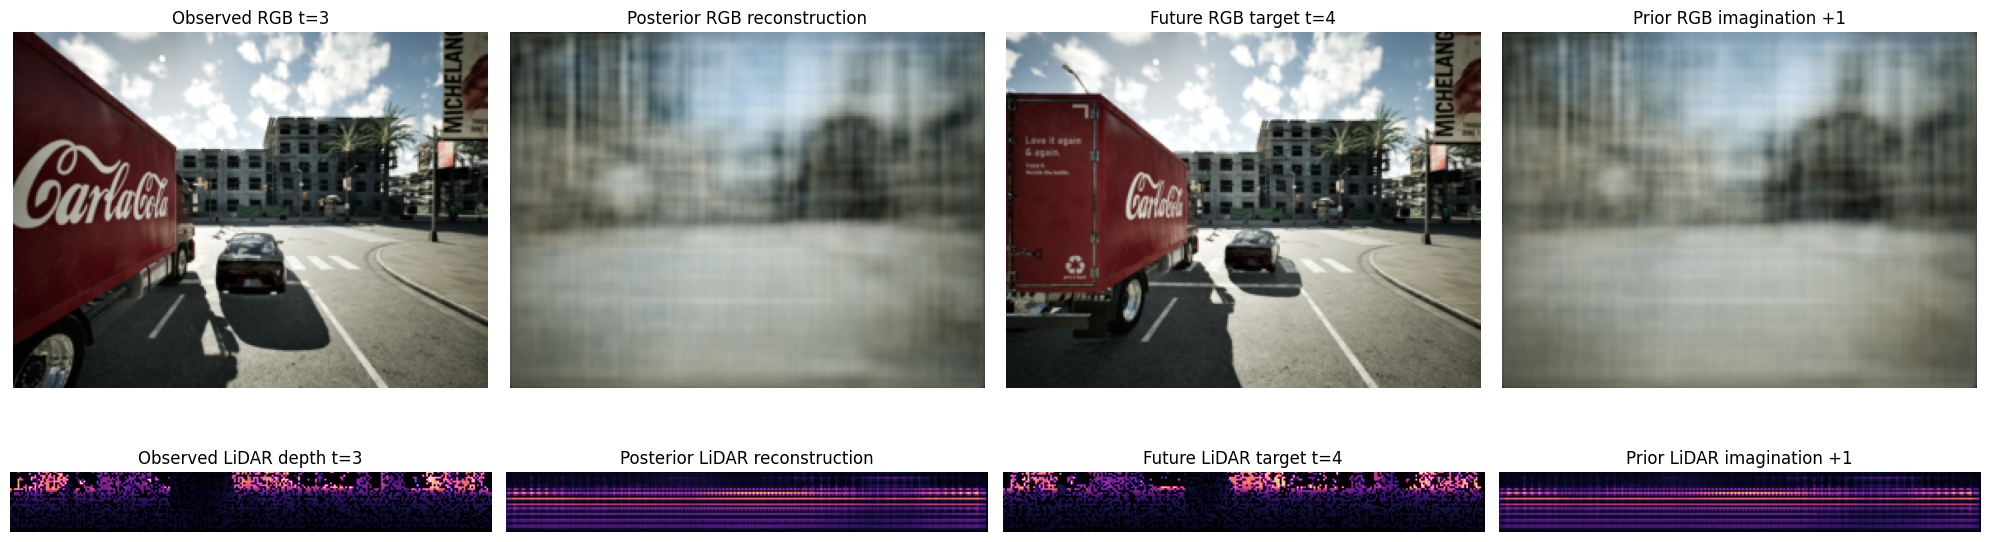

In [26]:
import glob
import matplotlib.pyplot as plt


def _checkpoint_search_root(save_dir="./logs", run_name=None):
    run_name = run_name or cfg.LOGGING.RUN_NAME
    return os.path.join(save_dir, run_name)


def _latest_checkpoint(save_dir="./logs", run_name=None):
    search_root = _checkpoint_search_root(save_dir, run_name)
    ckpts = glob.glob(os.path.join(search_root, "**", "*.ckpt"), recursive=True)
    return max(ckpts, key=os.path.getmtime) if ckpts else None


def _best_checkpoint(save_dir="./logs", run_name=None):
    """Return the run-scoped best checkpoint path, falling back to recent top-k."""
    run_name = run_name or cfg.LOGGING.RUN_NAME
    best_path = getattr(getattr(cfg, "LOGGING", SimpleNamespace()), "BEST_CHECKPOINT_PATH", None)
    if best_path and os.path.isfile(best_path):
        return best_path

    search_root = _checkpoint_search_root(save_dir, run_name)
    ckpts = [
        p for p in glob.glob(os.path.join(search_root, "**", "*.ckpt"), recursive=True)
        if os.path.basename(p) != "last.ckpt"
    ]
    return max(ckpts, key=os.path.getmtime) if ckpts else _latest_checkpoint(save_dir, run_name)


def _to_rgb_image(tensor):
    return tensor.detach().float().cpu().permute(1, 2, 0).clamp(0, 1)


def _to_depth_image(tensor):
    return tensor.detach().float().cpu()


@torch.no_grad()
def visualize_reconstruction(model=None, ds=None, sample_idx=0, obs_time_idx=-1, future_time_idx=0,
                             checkpoint_path=None, save_dir=None, log_root="./logs", run_name=None):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    run_name = run_name or cfg.LOGGING.RUN_NAME

    if ds is None:
        ds = MUVODataset(
            cfg.DATA.TRAIN_RUN,
            seq_len=cfg.RECEPTIVE_FIELD + cfg.FUTURE_HORIZON,
            stride=cfg.RECEPTIVE_FIELD * cfg.DATA.SAMPLE_EVERY_N,
            sample_every_n=cfg.DATA.SAMPLE_EVERY_N,
            image_input_size=cfg.DATA.IMAGE_INPUT_SIZE,
            rgb_recon_size=cfg.DATA.RGB_RECON_SIZE,
            lidar_size=cfg.DATA.LIDAR_RANGE_VIEW_SIZE,
            frame_step=cfg.DATA.FRAME_STEP,
        )

    if model is None:
        ckpt = checkpoint_path or _best_checkpoint(save_dir=log_root, run_name=run_name)
        if ckpt is None:
            raise RuntimeError(f"No checkpoint found for this run: {os.path.join(log_root, run_name)}")
        model = WorldModelTrainer.load_from_checkpoint(
            ckpt,
            cfg=cfg,
            lr=cfg.OPTIMIZER.LR,
            embedding_n_channels=128,
        )
        print(f"Loaded checkpoint: {ckpt}")

    model = model.to(device).eval()
    sample = ds[sample_idx]
    batch = {
        key: value.unsqueeze(0).to(device)
        for key, value in sample.items()
        if torch.is_tensor(value)
    }
    batch = model.prepare_custom_batch(batch)
    use_cuda_amp = device == "cuda"
    with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_cuda_amp):
        _, posterior_output, _, _, future_output = model._observe_and_imagine(batch)

    rf = cfg.RECEPTIVE_FIELD
    fh = cfg.FUTURE_HORIZON
    obs_t = obs_time_idx if obs_time_idx >= 0 else rf + obs_time_idx
    obs_t = max(0, min(obs_t, rf - 1))

    has_future = future_output is not None and fh > 0
    fut_t = max(0, min(future_time_idx, fh - 1)) if has_future else 0
    fut_batch_t = rf + fut_t

    input_rgb_obs = _to_rgb_image(batch["image_raw"][0, obs_t])
    pred_rgb_obs = _to_rgb_image(posterior_output["rgb_2"][0, obs_t])
    input_depth_obs = _to_depth_image(batch["lidar"][0, obs_t, 3])
    pred_depth_obs = _to_depth_image(posterior_output["lidar_reconstruction_2"][0, obs_t, 3])

    fig, axes = plt.subplots(2, 4 if has_future else 2, figsize=(20 if has_future else 10, 7))
    axes = np.asarray(axes)

    axes[0, 0].imshow(input_rgb_obs)
    axes[0, 0].set_title(f"Observed RGB t={obs_t}")
    axes[0, 1].imshow(pred_rgb_obs)
    axes[0, 1].set_title("Posterior RGB reconstruction")
    axes[1, 0].imshow(input_depth_obs, cmap="magma")
    axes[1, 0].set_title(f"Observed LiDAR depth t={obs_t}")
    axes[1, 1].imshow(pred_depth_obs, cmap="magma")
    axes[1, 1].set_title("Posterior LiDAR reconstruction")

    if has_future:
        target_rgb_future = _to_rgb_image(batch["image_raw"][0, fut_batch_t])
        pred_rgb_future = _to_rgb_image(future_output["rgb_2"][0, fut_t])
        target_depth_future = _to_depth_image(batch["lidar"][0, fut_batch_t, 3])
        pred_depth_future = _to_depth_image(future_output["lidar_reconstruction_2"][0, fut_t, 3])

        axes[0, 2].imshow(target_rgb_future)
        axes[0, 2].set_title(f"Future RGB target t={fut_batch_t}")
        axes[0, 3].imshow(pred_rgb_future)
        axes[0, 3].set_title(f"Prior RGB imagination +{fut_t + 1}")
        axes[1, 2].imshow(target_depth_future, cmap="magma")
        axes[1, 2].set_title(f"Future LiDAR target t={fut_batch_t}")
        axes[1, 3].imshow(pred_depth_future, cmap="magma")
        axes[1, 3].set_title(f"Prior LiDAR imagination +{fut_t + 1}")

    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        fname = f"{run_name}_reconstruction_s{sample_idx}.png"
        fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {Path(save_dir) / fname}")
    plt.show()


# Run manually after training if needed.
visualize_reconstruction(sample_idx=0, obs_time_idx=-1, future_time_idx=0,
                         save_dir=str(PROJECT_ROOT / "results" / "figures"))

Loaded TensorBoard scalars from: ./logs/trainer11_reviewed_v3_alldata/version_0/events.out.tfevents.1778165509.DESKTOP-0DP4OD6.783933.1


/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from current font.
  fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from current font.
  fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
/tmp/ipykernel_783933/484551921.py:90: UserWarning: Glyph 54980 (\N{HANGUL

Saved: /home/carol/chaeyeon-kim/alpha26/results/figures/trainer11_reviewed_v3_alldata_loss_metrics.png


/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_783933/484551921.py:92: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from current font.
  plt.tight_layout()
/home/carol/exit/envs/kcy-alpha/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  f

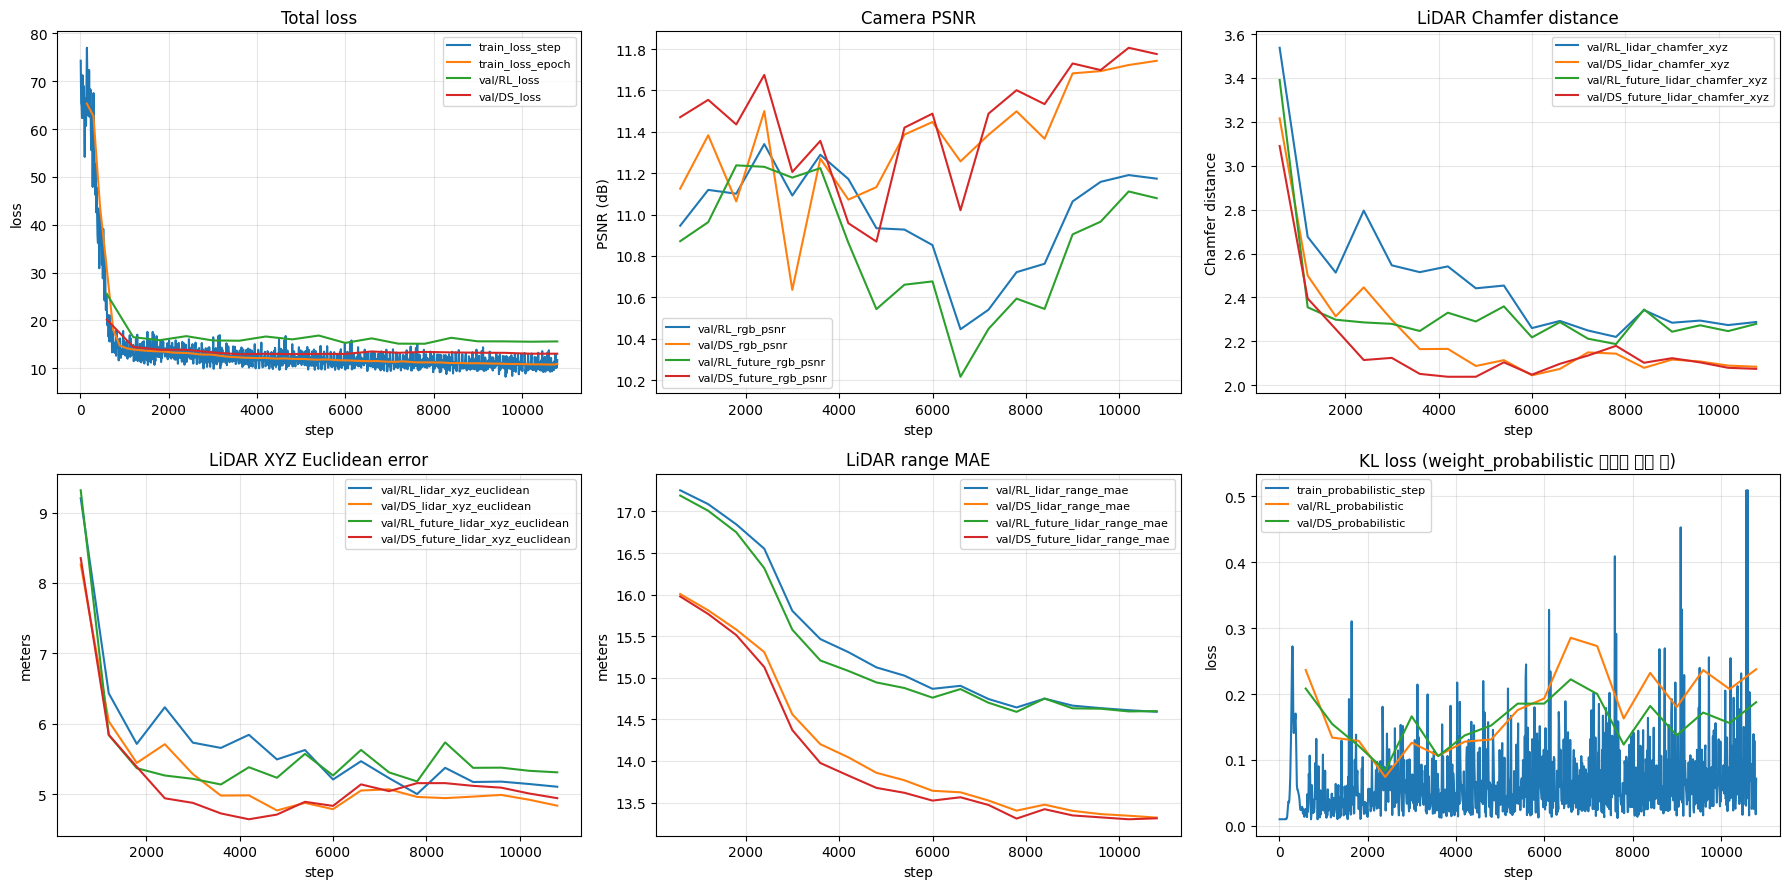

In [27]:
#######################
# Loss / metric plots from TensorBoard logs
#######################
import glob
import os
import matplotlib.pyplot as plt

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except ImportError as exc:
    raise ImportError("TensorBoard is required. Install it in the active environment and rerun this cell.") from exc


def _latest_event_file(log_root="./logs", run_name=None):
    run_name = run_name or cfg.LOGGING.RUN_NAME
    search_root = os.path.join(log_root, run_name)
    event_files = glob.glob(os.path.join(search_root, "**", "events.out.tfevents.*"), recursive=True)
    if not event_files:
        raise FileNotFoundError(f"TensorBoard event file not found: {search_root}")
    return max(event_files, key=os.path.getmtime)


def load_tensorboard_scalars(event_file=None, log_root="./logs", run_name=None):
    event_file = event_file or _latest_event_file(log_root=log_root, run_name=run_name)
    accumulator = EventAccumulator(event_file)
    accumulator.Reload()
    scalars = {}
    for tag in accumulator.Tags().get("scalars", []):
        events = accumulator.Scalars(tag)
        scalars[tag] = {
            "step": [event.step for event in events],
            "value": [event.value for event in events],
        }
    print(f"Loaded TensorBoard scalars from: {event_file}")
    return scalars


def _plot_tags(ax, scalars, tags, title, ylabel):
    found = False
    for tag in tags:
        if tag in scalars:
            ax.plot(scalars[tag]["step"], scalars[tag]["value"], label=tag)
            found = True
    ax.set_title(title)
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if found:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No matching scalar", ha="center", va="center", transform=ax.transAxes)


def plot_loss_and_eval_metrics(log_root="./logs", run_name=None, save_dir=None):
    run_name = run_name or cfg.LOGGING.RUN_NAME
    scalars = load_tensorboard_scalars(log_root=log_root, run_name=run_name)
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    _plot_tags(
        axes[0, 0], scalars,
        ["train_loss_step", "train_loss_epoch", "val/RL_loss", "val/DS_loss"],
        "Total loss", "loss",
    )
    _plot_tags(
        axes[0, 1], scalars,
        ["val/RL_rgb_psnr", "val/DS_rgb_psnr", "val/RL_future_rgb_psnr", "val/DS_future_rgb_psnr"],
        "Camera PSNR", "PSNR (dB)",
    )
    _plot_tags(
        axes[0, 2], scalars,
        ["val/RL_lidar_chamfer_xyz", "val/DS_lidar_chamfer_xyz", "val/RL_future_lidar_chamfer_xyz", "val/DS_future_lidar_chamfer_xyz"],
        "LiDAR Chamfer distance", "Chamfer distance",
    )
    _plot_tags(
        axes[1, 0], scalars,
        ["val/RL_lidar_xyz_euclidean", "val/DS_lidar_xyz_euclidean", "val/RL_future_lidar_xyz_euclidean", "val/DS_future_lidar_xyz_euclidean"],
        "LiDAR XYZ Euclidean error", "meters",
    )
    _plot_tags(
        axes[1, 1], scalars,
        ["val/RL_lidar_range_mae", "val/DS_lidar_range_mae", "val/RL_future_lidar_range_mae", "val/DS_future_lidar_range_mae"],
        "LiDAR range MAE", "meters",
    )
    _plot_tags(
        axes[1, 2], scalars,
        ["train_probabilistic_step", "val/RL_probabilistic", "val/DS_probabilistic"],
        "KL loss (weighted)", "loss",
    )

    plt.tight_layout()
    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        fname = f"{run_name}_loss_metrics.png"
        fig.savefig(Path(save_dir) / fname, dpi=150, bbox_inches="tight")
        print(f"Saved: {Path(save_dir) / fname}")
    plt.show()
    return scalars


# Read TensorBoard scalars only from the current RUN_NAME directory.
scalars = plot_loss_and_eval_metrics(save_dir=str(PROJECT_ROOT / "results" / "figures"))